# Introduction

This notebook presents a multi-scenario analysis of the carbon saving achieved by the scheduler under different circumstances.

First of all, we aim to evaluate various policies:
- `baseline`: the baseline algorithm, which schedules requests with the most accurate flavour as they arrive, without considering carbon intensity or cap levels.
- **Carbonshift**: our scheduler running carbonshift with different batch sizes. This presents two possible fallback policies to deal with infeasibility (no assignment yields a feasible solution with respect to the error threshold):
  - `min_error_greedy` (*"greedy fallback"*): scheduler uses only the *Accurate* flavour, placing requests in the slots with the lowest carbon intensity, until the error threshold is reached. 
  - `carryover`: the scheduler will consider the previous slot's amount of assigned requests as reference, assuming that about the same amount of requests will arrive in the current slot. This relaxes the error threshold, avoiding to "panick" when the window shifts (which may lead to infeasibility).
    - Actually only a portion (e.g. 80%) of the previous slot's assigned requests is considered, to avoid overestimating the current slot's amount of requests, and if infeasibility is  still present on the next window movement, the portion decreases further by a fixed amount (e.g. 20%) until it reaches 0%.
    - Even though unlikely, this policy falls back to `min_error_greedy` if infeasibility persists after injecting the carryover amount of requests.
- **Online policies**
  - `greedy_singleton`: as requests arrive, for each request, use the cheapest flavour allowed by the error threshold, find the cheapest slot for each request as it arrives, taking into account the current slot's carbon intensity and the cap level. If infeasibility occurs, *greedy fallback* is applied.
    - This is analogous to **carbonshift** with batch size 1, but is simpler in the implementation.
    - Note that the amount of possible assignments is rather low: for 14 window slots and 3 flavours, there are only 42 possible assignments for each request.
  - **Swarm policies**
    - `ant_colony`: the ant colony optimization algorithm, which benefits from higher batch sizes, as it can solver bigger subproblems and find better suboptimal solutions, exploring a wider space of solutions. 
    - (Multi-armed) `bandit`: the multi-armed bandit algorithm, which balances exploration and exploitation to find good assignments over time. The online version does not exhibit a strong degradation with respect to the offline version.
- **Offline policies**\
These are the same as the online policies, but are executed offline, and are used only as a reference for testing.
  - `greedy_cheapest`: same as `greedy_singleton` above, but in an offline single threaded fashion, no concurrency occurs.
  - `ant_colony`: same as above, but in an offline single threaded fashion, no concurrency occurs. Having the entire window available, the ant colony algorithm can find better solutions than in the online version. A solution represents the assignment of all requests, opposed to finding the best assignment for N requests at a time, as in the online version.
  - `bandit`: same as above, but in an offline single threaded fashion, no concurrency occurs. Here, bandit the exploration/exploitation tradeoff applies in the same way as in the online version.

*Note:* names in `backticks` are the same names used in the dataframe tables displayed below; do not expect to read "DP-solver" or "carbonshift" there; `carryover` and `min_error_greedy` refer to the carbonshift solver, only distinguishing the fallback policy.


## Information on the tests

Tests are conducted over two main **scenarios**:
  - `high_load_1500_92`: scenario with (on average) 1500 requests per slot (randomness seed `92`) 
  - `xhigh_load_2000_120`: scenario with (on average) 2000 requests per slot (randomness seed `120`) 

The maximum **deadline** slack for requests is set to 14 slots, matching the future window for possible assignments, which is also 14 slots.\
Time slots are meant to be considered **hourly**, so that each slot represents one hour.\
Given that the carbon intensity pattern presents peaks and valleys every 12 hours following the light and dark cycles of the day, with 14 hourly slots, the scheduling of requests can take advantage of the whole variation of the pattern, always seeing both a valley and a peak (not two valleys nor two peaks).\
Using 30min slots (as in previous Carbonshift literature) would double the number of slots in the same 14-hour window to still be able to exploit CI variations, making the tests even more computationally intensive. For testing purposes, we can stick to hourly slots.

The moving **window** is `[-12,+14]` plus another 12 slots in the past with decaying weights applied (from 12/13 to 1/13).
The average error must be kept below the threshold (`4.0` unless otherwise specified), both globally and within each moving window.

Three execution **flavours** are considered:
| flavour | error | exec time |
|---------|-------|-----------|
| Accurate | 0.0 | 60s |
| Balanced | 2.5 | 30s |
| Fast  | 5.0 | 10s |

Beam **pruning** with 1200 retained states is applied where `batch_size >= 8`.

**Cap levels** define the multiplying factor applied to CI when exceeding an amount of requests assigned to a time slot. That is, requests assigned beyond the cap level will have their carbon intensity cost multiplied by the corresponding factor.\
*All policies* take the defined cap levels into account when scheduling requests, except for `baseline`.

### Metrics

The primary metrics used to evaluate the performance of the scheduling policies are:
- `carbon_saving`: measures the reduction in carbon emissions achieved by the scheduling policy.
- `solver_time_ms_avg`: the average time taken by the solver to compute the schedule, in milliseconds.
- `elapsed_seconds`: the total elapsed time for the scheduling process, in seconds, accounting also for any overhead outside the solver computation.

There are some execution parameters which have been varied in the experiments, in order to study their impact on the performance metrics. These include:
- `parallelism`: the number of parallel solver threads used by the scheduler.
- `batch_size`: the number of requests processed in each batch by the scheduler. 
  - Tests have different configurations, this is in `[1,4,6,8,22]` for comprehensive tests with the Carbonshift DP solver. In case of online policies, it goes up to `[1,8,22,48,96]`. Smaller/specific tests may use fewer batch sizes.
- `RB_max_consecutive`: the maximum number of consecutive rollbacks allowed during the scheduling process.
  - Recall: rollback is applied when, due to stale data in case of parallelism, different threads make assignments which lead to unexpectedly exceeding a cap level in some time slot.
- `threshold`: error threshold applied both globally and within each moving window.
- `cap_levels`: the defined cap levels and their corresponding multiplying factors. In general 2 cap levels are defined: one for moderate exceedance and one triggering strong rebound effect.
```json
      "capacity_tiers": [
        {
          "max_requests": 2000,
          "multiplier": 1.0
        },
        {
          "max_requests": 3000,
          "multiplier": 1.5
        },
        {
          "max_requests": null,
          "multiplier": 5.0
        }
      ]
```
this reads as: "up to 2000 requests, the multiplier is 1.0; up to 3000 requests, the multiplier is 1.5; beyond 3000 requests, the multiplier is 5.0."


In [ ]:
from pathlib import Path
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

plt.rcParams['figure.dpi'] = 85 
REPO_ROOT = Path().resolve()
RESULTS_DIR = REPO_ROOT / "results"

In [45]:
# Makes table interactive in html
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)


# Fix table alignment in HTML exported notebook
from IPython.display import display, HTML

display(HTML("""
<style>
    /* Individua i contenitori delle celle Markdown in VSCode/Jupyter */
    .rendered_html, 
    .jp-RenderedHTMLCommon, 
    div[data-mime-type="text-markdown"] {
        display: flex !important;
        flex-direction: column !important;
        align-items: flex-start !important;
    }

    /* Ripristina i margini corretti per la tabella */
    .rendered_html table, 
    .jp-RenderedHTMLCommon table,
    div[data-mime-type="text-markdown"] table {
        margin-left: 0 !important;
        margin-right: auto !important;
        display: table !important;
    }
</style>
"""))

In [ ]:
%%capture
# disable output for this cell

# this loads and aggregates the battery test results
from save_results import aggregate_and_save
aggregate_and_save(prefix_regex=r"^(cfg)_test(1|2|3|4|5|6|7|8|9|10|11|12|13|14)_")

In [32]:
# Load csv file 
output_csv = RESULTS_DIR / "aggregated_battery_results.csv"
df_all = pd.read_csv(output_csv)

# if present, rename infeasibility_mode column to "policy"
if "infeasibility_mode" in df_all.columns:
    df_all = df_all.rename(columns={"infeasibility_mode": "policy"})

# display all columns option
pd.set_option("display.max_columns", None)

# filter out runs whose path contains test1_, since test2 is with varying threshold
df = df_all[df_all["path"].str.contains("cfg_test1_")]


# display only 5 rows to get a sample
# Note: this has been comprehensively examined manually. 
#       Visualization will be done in subsequent cells.
pd.set_option("display.max_rows", 5)
display(df.sort_values(by=["scenario_id", "policy", "batch_size","final_global_error", "parallelism","RB_max_consecutive","batch_size"]))

run_id          scenario_id  requests_in  batch_size  \
211    cfg    high_load_1500_92       107064           1   
171    cfg    high_load_1500_92       107064           1   
..     ...                  ...          ...         ...   
417    cfg  xhigh_load_2000_120       144963           1   
413    cfg  xhigh_load_2000_120       144963           1   

                      policy  parallelism  solver_time_ms_avg  \
211                carryover            1                4.91   
171                carryover            8               15.08   
..                       ...          ...                 ...   
417  online_greedy_singleton            8               20.56   
413  online_greedy_singleton            8               20.48   

     elapsed_seconds  carbon_cost  carbon_saving  req_assigned_with_GF  \
211           655.40     66870.19          68.77                    98   
171           496.70     69874.95          67.36                  1453   
..               ...          ...            ...                   ...   
417           959.46    126398.30          64.96                     0   
413          1016.04    123384.27          65.79                     0   

     total_RBs  peak_consecutive_RBs  RB_max_consecutive  \
211          0                     0                   0   
171          0                     0                   0   
..         ...                   ...                 ...   
417        131                     1                   8   
413        109                     1                   4   

     peak_concurrent_workers  avg_concurrent_workers online_swarm_mode  \
211                        1                    1.00             merge   
171                        8                    5.77             merge   
..                       ...                     ...               ...   
417                        8                    6.10             merge   
413                        8                    5.92             merge   

     baseline_carbon_cost  final_global_error  avg_global_error_per_slot  \
211             214108.17                4.00                       4.00   
171             214108.17                4.00                       4.00   
..                    ...                 ...                        ...   
417             360701.75                3.98                       3.98   
413             360701.75                3.99                       3.98   

                                                  path  
211  cfg_test1_dp_0_0819_1138_1_roll0_0_F_M/high_lo...  
171  cfg_test1_dp_0_0816_2106_8_roll0_0_F_M/high_lo...  
..                                                 ...  
417  cfg_test1_greedy_singleton_4_0819_0100_8_roll8...  
413  cfg_test1_greedy_singleton_2_0819_0008_8_roll4...  

[288 rows x 21 columns]

## Purpose
Our intent is to assess the performance of different scheduling policies in terms of `carbon_saving`, `solver_time_ms_avg`, and `elapsed_seconds`, and see how different parameters, such as `batch_size` and `parallelism`, affect such performance, in order to identify the most effective configurations in this simulated environment.

`carbon_saving` and `solver_time_ms_avg`/`elapsed_seconds` are the primary metrics since they represent the effectiveness against the cost of the scheduling process.\
Clearly, execution time (especially `elapsed_seconds`) may be affected by other unforeseen factors.

## Visualization

We want to analyze these fields `carbon_saving`,`solver_time_ms_avg`,`elapsed_seconds`.
We must visualize but separating on policies.
The X axis will be the `batch_size` and the Y axis will be the value of the field we are analyzing.


Given that there are multiple runs, we will use the average value of the field for each `batch_size` and `policy` to provide a visual representation.

We will stick to **online policies** evaluation for now.
**Offline policies** work better in general but are there just for reference, as they are not applicable in real-time scenarios.


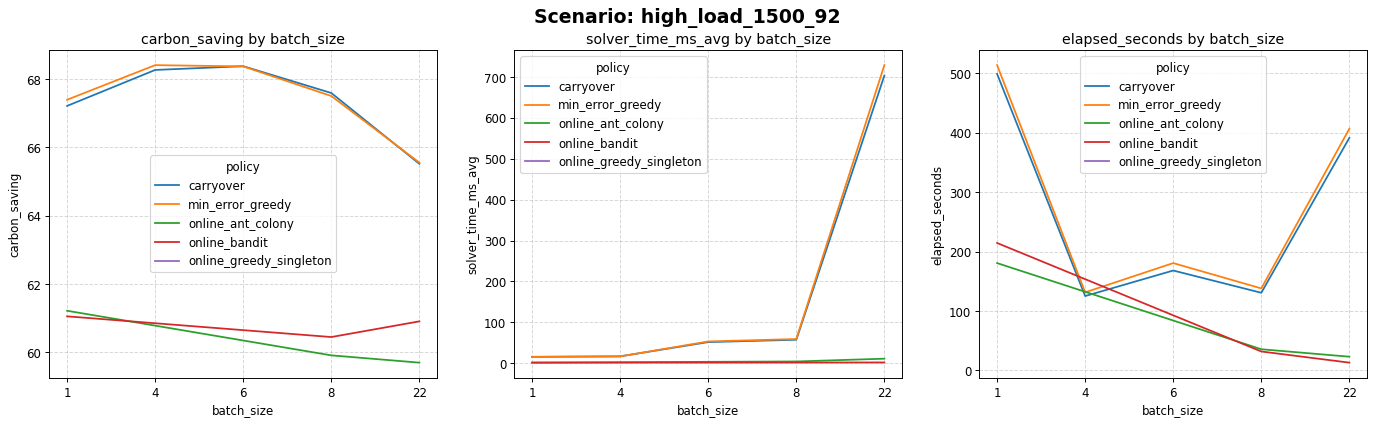

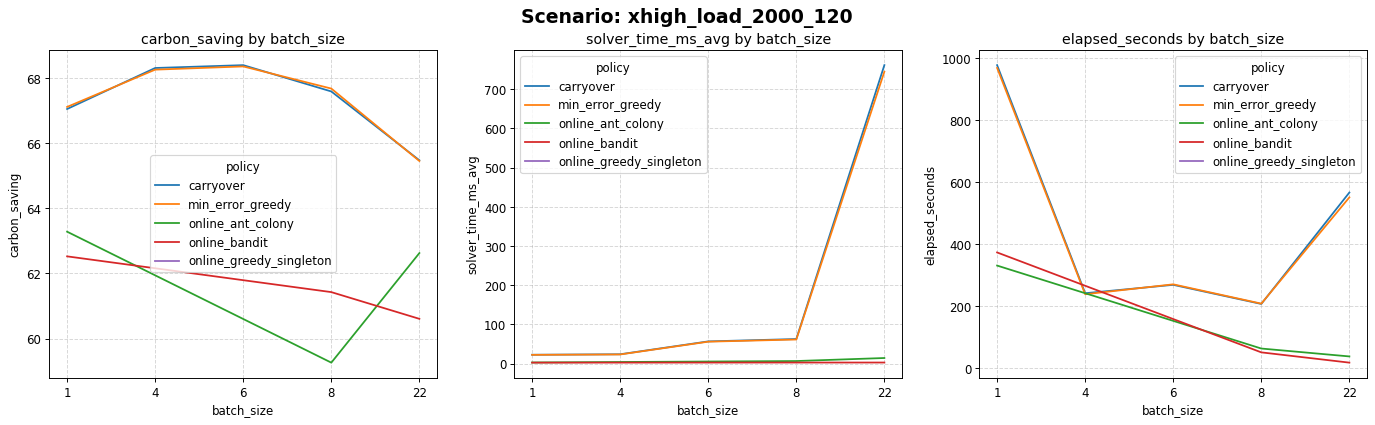

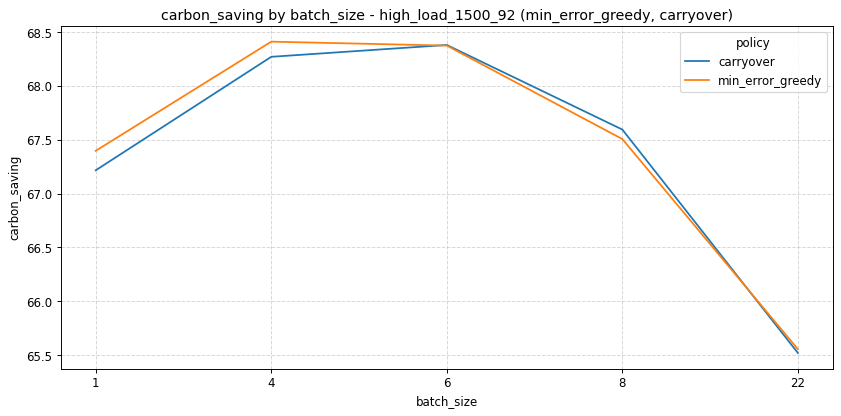

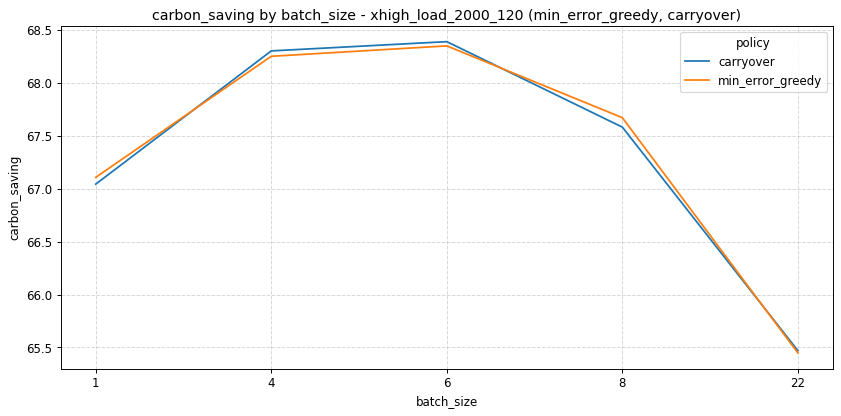

In [33]:
# Work on a clean dataframe
plot_df = df.copy()
plot_df["batch_size"] = pd.to_numeric(plot_df["batch_size"], errors="coerce")
plot_df = plot_df.dropna(subset=["batch_size", "policy"]).copy()

def three_subplots_figure(plot_df, scenario_id, metrics):
    scenario_df = plot_df[plot_df["scenario_id"] == scenario_id].copy()
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
    if len(metrics) == 1:
        axes = [axes]

    # Set the global title for the figure
    fig.suptitle(f"Scenario: {scenario_id}", fontsize=16, fontweight="bold")

    x_order = sorted(scenario_df["batch_size"].dropna().unique().tolist())
    x_map = {v: i for i, v in enumerate(x_order)}

    for ax, metric in zip(axes, metrics):
        grouped = (
            scenario_df.groupby(["batch_size", "policy"], as_index=False)[metric]
            .mean()
            .sort_values(["policy", "batch_size"])
        ).copy()
        grouped["x_pos"] = grouped["batch_size"].map(x_map)

        sns.lineplot(
            data=grouped,
            x="x_pos",
            y=metric,
            hue="policy",
            markers=True,
            dashes=True,
            errorbar=None,
            ax=ax,
            sort=False,
        )
        ax.set_title(f"{metric} by batch_size")
        ax.set_xlabel("batch_size")
        ax.set_ylabel(metric)
        ax.set_xticks(range(len(x_order)))
        ax.set_xticklabels([str(v) for v in x_order])
        ax.grid(True, linestyle="--", alpha=0.5)
    
    plt.show()


def special_modes_figure(plot_df, scenario_id, special_modes):
    special_df = plot_df[
        (plot_df["scenario_id"] == scenario_id) &
        (plot_df["policy"].isin(special_modes))
    ].copy()

    x_order = sorted(special_df["batch_size"].dropna().unique().tolist())
    x_map = {v: i for i, v in enumerate(x_order)}
    grouped = (
        special_df.groupby(["batch_size", "policy"], as_index=False)["carbon_saving"]
        .mean()
        .sort_values(["policy", "batch_size"])
    ).copy()
    grouped["x_pos"] = grouped["batch_size"].map(x_map)

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=grouped,
        x="x_pos",
        y="carbon_saving",
        hue="policy",
        markers=True,
        dashes=True,
        errorbar=None,
        sort=False,
    )
    plt.title(f"carbon_saving by batch_size - {scenario_id} ({', '.join(special_modes)})")
    plt.xlabel("batch_size")
    plt.ylabel("carbon_saving")
    plt.xticks(range(len(x_order)), [str(v) for v in x_order])
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Three subplots for each scenario
for scenario_id in sorted(plot_df["scenario_id"].unique()):
    three_subplots_figure(plot_df, scenario_id=scenario_id, metrics=["carbon_saving", "solver_time_ms_avg", "elapsed_seconds"])

# Separate plot for carbon_saving limited to min_error_greedy and carryover, one figure per scenario
for scenario_id in sorted(plot_df["scenario_id"].unique()):
    special_modes_figure(plot_df, scenario_id=scenario_id, special_modes=["min_error_greedy", "carryover"])



#### Focus on carbonshift solver with `[4,6,8]` batch sizes
Let's narrow this down a little bit.\
Examine *average*, *min*, *max* values for `carbon_saving` and `elapsed_seconds` with `batch_size` in `[4,6,8]` and `policy` in `["min_error_greedy", "carryover"]`

scenario_id            policy  batch_size  carbon_saving_avg  \
0     high_load_1500_92         carryover           4          68.270000   
1     high_load_1500_92         carryover           6          68.380000   
2     high_load_1500_92         carryover           8          67.594167   
3     high_load_1500_92  min_error_greedy           4          68.410833   
4     high_load_1500_92  min_error_greedy           6          68.374167   
5     high_load_1500_92  min_error_greedy           8          67.505833   
6   xhigh_load_2000_120         carryover           4          68.300833   
7   xhigh_load_2000_120         carryover           6          68.388333   
8   xhigh_load_2000_120         carryover           8          67.580833   
9   xhigh_load_2000_120  min_error_greedy           4          68.250000   
10  xhigh_load_2000_120  min_error_greedy           6          68.348333   
11  xhigh_load_2000_120  min_error_greedy           8          67.670000   

    carbon_saving_min  carbon_saving_max  elapsed_seconds_avg  \
0               67.90              69.32           125.050833   
1               67.91              69.38           168.031667   
2               66.67              69.81           130.556667   
3               68.08              69.35           131.288333   
4               67.79              69.66           180.546667   
5               66.42              69.80           137.930833   
6               67.93              69.40           242.566667   
7               68.01              69.96           269.560833   
8               66.90              70.12           207.990833   
9               67.85              69.65           239.234167   
10              67.84              69.85           271.242500   
11              67.05              70.15           209.007500   

    elapsed_seconds_min  elapsed_seconds_max  
0                104.45               204.88  
1                133.54               473.20  
2                101.84               379.14  
3                106.99               239.44  
4                131.14               570.99  
5                 98.60               426.26  
6                215.84               384.21  
7                218.97               656.50  
8                166.76               531.29  
9                201.61               370.95  
10               215.39               697.41  
11               160.16               577.20

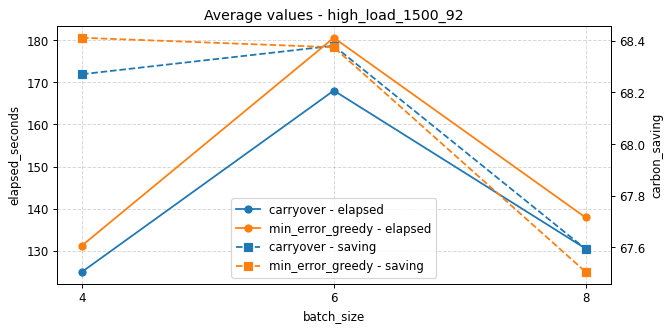

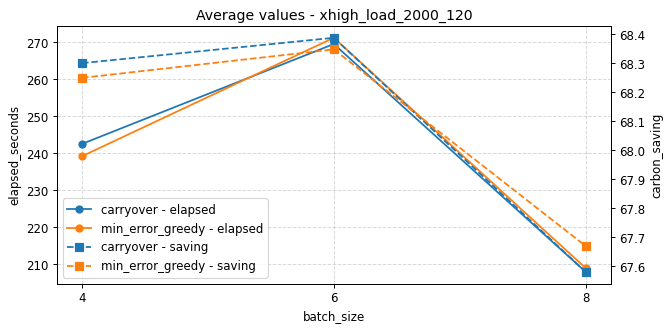

In [34]:
filtered = plot_df[
    (plot_df["batch_size"].isin([4, 6, 8])) &
    (plot_df["policy"].isin(["min_error_greedy", "carryover"]))
].copy()

summary = (
    filtered.groupby(["scenario_id", "policy", "batch_size"], as_index=False)
    .agg(
        carbon_saving_avg=("carbon_saving", "mean"),
        carbon_saving_min=("carbon_saving", "min"),
        carbon_saving_max=("carbon_saving", "max"),
        elapsed_seconds_avg=("elapsed_seconds", "mean"),
        elapsed_seconds_min=("elapsed_seconds", "min"),
        elapsed_seconds_max=("elapsed_seconds", "max"),
    )
    .sort_values(["scenario_id", "policy", "batch_size"])
    .reset_index(drop=True)
)
pd.set_option("display.max_rows", None)
display(summary)

# Compact plot per scenario: average values for carbon_saving and elapsed_seconds
for scenario_id in sorted(filtered["scenario_id"].unique()):
    s = summary[summary["scenario_id"] == scenario_id]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()

    for mode, g in s.groupby("policy"):
        ax.plot(g["batch_size"], g["elapsed_seconds_avg"],
                marker="o", linestyle="-", label=f"{mode} - elapsed")
        ax2.plot(g["batch_size"], g["carbon_saving_avg"],
                 marker="s", linestyle="--", label=f"{mode} - saving")

    ax.set(
        title=f"Average values - {scenario_id}",
        xlabel="batch_size",
        ylabel="elapsed_seconds",
        xticks=sorted(s["batch_size"].unique()),
    )
    ax2.set_ylabel("carbon_saving")

    ax.grid(True, linestyle="--", alpha=0.5)

    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [l.get_label() for l in lines], loc="best")

    fig.tight_layout()
    plt.show()

#### Considerations
`carryover` provides similar (or slightly better) carbon savings while keeping the same or lower elapsed seconds compared to `min_error_greedy`.

Although, it could be that the minor differences in the elapsed seconds are due to external factors such as system load or background processes.

The carbon saving differences, in fact, are almost negligible, and may be due to parallelism effects in the system rather than the occasional enforcement of the infeasibility policy.


We will stick with the `carryover` policy for further analysis, for now.

## Parallelism and rollback

These two parameters clearly interact between them, as higher parallelism implies more data staleness, which can lead to more frequent rollbacks.

### Parallelism evaluation
Let's understand if more parallelism yields less elapsed time or better savings (most likely won't, since parallelism implies use of stale assignments data and so unexpected exceeding of cap levels).

In [47]:
# Get only carryover and min_error_greedy modes
df_gr_ret = df[df["policy"].str.contains("carryover|min_error_greedy")]
# For each scenario and for each N, we want to know a much elapsed_time is spared with runs having parallelism > 1 compared to runs with parallelism = 1
group_cols = ["scenario_id", "batch_size"]

# Baseline: get max elapsed_seconds among the runs with parallelism=1
baseline = (
    df_gr_ret[df_gr_ret["parallelism"] == 1]
    .groupby(group_cols)
    .agg(
        elapsed_parallelism_1=("elapsed_seconds", "max"),
        carbon_parallelism_1=("carbon_saving", "max")
    )
    .reset_index()
)

# Run with parallelism > 1
parallel = (
    df_gr_ret[df_gr_ret["parallelism"] > 1]
    [
        group_cols
        + [
            "parallelism",
            "elapsed_seconds",
            "peak_concurrent_workers",
            "avg_concurrent_workers",
            "policy",
            "RB_max_consecutive",
            "total_RBs",
            "carbon_saving"
        ]
    ]
)

comparison = parallel.merge(
    baseline,
    on=group_cols,
    how="inner",
)

comparison["seconds_saved"] = (
    comparison["elapsed_parallelism_1"]
    - comparison["elapsed_seconds"]
)

comparison["speedup_pct"] = (
    comparison["seconds_saved"]
    / comparison["elapsed_parallelism_1"]
    * 100
)

comparison["carbon_improvement"] = (
    comparison["carbon_saving"] -
    comparison["carbon_parallelism_1"]
)

# Set columns ordering for comparison for better readability
comparison = comparison[
    [
        "scenario_id",
        "batch_size",
        "parallelism",
        "elapsed_seconds",
        "elapsed_parallelism_1",
        "seconds_saved",
        "speedup_pct",
        "carbon_saving",
        "carbon_improvement",
        "carbon_parallelism_1",
        "peak_concurrent_workers",
        "avg_concurrent_workers",
        "policy",
        "RB_max_consecutive",
        "total_RBs",
    ]
] 


def agg_foo (df):
    return (
        df
        .groupby("parallelism")
        .agg(
            runs=("scenario_id", "count"),
            avg_saved_seconds=("seconds_saved", "mean"),
            median_saved_seconds=("seconds_saved", "median"),
            avg_speedup_pct=("speedup_pct", "mean"),
            max_speedup_pct=("speedup_pct", "max"),
            median_speedup_pct=("speedup_pct", "median"),
            avg_carbon_improvement=("carbon_improvement", "mean"),
            max_carbon_improvement=("carbon_improvement", "max"),
            avg_peak_workers=("peak_concurrent_workers", "mean"),
            avg_workers=("avg_concurrent_workers", "mean"),
            avg_rollbacks=("total_RBs", "mean"),
        )
    )

# display(comparison.head(10))
summary = agg_foo(comparison)


# display summary for each batch_size
for batch_size, df_batch in comparison.groupby("batch_size"):
    print("-" * 140)
    print(f"Summary for batch_size={batch_size}")
    display(agg_foo(df_batch))

# print line of separation before displaying the overall summary
print(("-" * 140 + "\n") * 2, end="")
print("Displaying overall summary")
display(summary)

--------------------------------------------------------------------------------------------------------------------------------------------
Summary for batch_size=1


runs  avg_saved_seconds  median_saved_seconds  avg_speedup_pct  \
parallelism                                                                   
8              20           312.9815               317.600        31.383463   
14              4           306.1550               305.815        31.217021   
20             20           272.8265               257.735        27.289187   

             max_speedup_pct  median_speedup_pct  avg_carbon_improvement  \
parallelism                                                                
8                  37.516550           31.508306                 -1.3955   
14                 34.996760           31.100362                 -1.8650   
20                 31.714978           27.893244                 -1.6725   

             max_carbon_improvement  avg_peak_workers  avg_workers  \
parallelism                                                          
8                             -0.93               8.0       5.7395   
14                            -1.39              14.0       7.4450   
20                            -1.24              20.0       7.2005   

             avg_rollbacks  
parallelism                 
8                    47.75  
14                    0.00  
20                   64.00

--------------------------------------------------------------------------------------------------------------------------------------------
Summary for batch_size=4


runs  avg_saved_seconds  median_saved_seconds  avg_speedup_pct  \
parallelism                                                                   
8              20            142.838               139.410        46.837421   
14              4            138.215               139.000        46.144435   
20             20            132.624               126.675        43.564540   

             max_speedup_pct  median_speedup_pct  avg_carbon_improvement  \
parallelism                                                                
8                  56.377381           46.331902                  -1.127   
14                 55.316572           45.689119                  -1.510   
20                 51.269629           43.628171                  -1.418   

             max_carbon_improvement  avg_peak_workers  avg_workers  \
parallelism                                                          
8                             -0.84               8.0       6.5015   
14                            -1.15              14.0       8.8800   
20                            -0.93              20.0       9.1460   

             avg_rollbacks  
parallelism                 
8                   130.35  
14                    0.00  
20                  188.40

--------------------------------------------------------------------------------------------------------------------------------------------
Summary for batch_size=6


...

runs  avg_saved_seconds  median_saved_seconds  avg_speedup_pct  \
parallelism                                                                   
8              20           359.1505               356.875        71.931367   
14              4           362.5500               363.430        72.787718   
20             20           356.5485               349.875        71.421584   

             max_speedup_pct  median_speedup_pct  avg_carbon_improvement  \
parallelism                                                                
8                  76.108478           72.245322                 -2.2630   
14                 76.868578           72.560413                 -2.8525   
20                 75.826960           71.204955                 -2.9060   

             max_carbon_improvement  avg_peak_workers  avg_workers  \
parallelism                                                          
8                             -1.66               8.0       7.3830   
14                            -2.42              14.0      10.8975   
20                            -2.29              20.0      11.9410   

             avg_rollbacks  
parallelism                 
8                   254.15  
14                    0.00  
20                  387.50

--------------------------------------------------------------------------------------------------------------------------------------------
Summary for batch_size=22


runs  avg_saved_seconds  median_saved_seconds  avg_speedup_pct  \
parallelism                                                                   
8              20          1010.3015              1008.750        70.583898   
14              4          1060.2850              1055.805        74.502385   
20             20          1052.2950              1014.740        73.525845   

             max_speedup_pct  median_speedup_pct  avg_carbon_improvement  \
parallelism                                                                
8                  73.219572           70.302965                 -3.4200   
14                 76.636461           74.751203                 -4.3725   
20                 77.793893           77.133051                 -4.1305   

             max_carbon_improvement  avg_peak_workers  avg_workers  \
parallelism                                                          
8                             -2.67               8.0       7.6000   
14                            -4.13              14.0      12.6875   
20                            -3.09              20.0      17.2160   

             avg_rollbacks  
parallelism                 
8                   336.10  
14                    0.00  
20                  813.15

--------------------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------
Displaying overall summary


runs  avg_saved_seconds  median_saved_seconds  avg_speedup_pct  \
parallelism                                                                   
8             100           454.4092               393.515        58.316248   
14             20           462.5520               386.270        59.097333   
20            100           451.9849               379.660        57.296773   

             max_speedup_pct  median_speedup_pct  avg_carbon_improvement  \
parallelism                                                                
8                  76.612550           67.833715                 -1.9054   
14                 77.032873           67.341951                 -2.4675   
20                 77.793893           67.276705                 -2.3776   

             max_carbon_improvement  avg_peak_workers  avg_workers  \
parallelism                                                          
8                             -0.84               8.0       6.8920   
14                            -1.15              14.0      10.0160   
20                            -0.93              20.0      11.3463   

             avg_rollbacks  
parallelism                 
8                   194.68  
14                    0.00  
20                  351.57

### Parallelism is useful
The optimization outcome is slightly worse, compared to non-parallel, but not significantly: for N=4|6, the reduction in carbon_saving is about -1.5/1.7%.

Instead, parallelism yields a significant reduction in `elapsed_seconds`. Speedup peaks at 76% for N=6|8, and yields on average a 46% reduction for N=4. The speedup is less pronounced for N=1, but still yields a 30% reduction.


`avg_workers` (indicating the average number of simultaneous workers) stays at 11 even for `parallelism=20` probably due to my **hardware capabilities**, despite having set a higher number of threads dedicated to WSL.

### Rollback evaluation

Rollback is applied when, due to stale assignment data, sibling worker threads make assignments which lead to exceeding a cap level in some time slots, when, instead, from the perspective of the thread itself they would not have.

To understand if rollback impact the saving positively, we follow this strategy:
 - Get the top 5 runs for carbon saving for one scenario. 
   - Check how many of them have total_RBs > 0.
 - Get the runs with total_RBs > 0 and measure the average carbon saving and elapsed_time for them.
   - Compare with the average carbon saving and elapsed_time for runs with no rollbacks.


Top 5 runs for xhigh_load_2000_120 by carbon_saving:


batch_size  parallelism            policy  carbon_saving  \
219           8            1  min_error_greedy          70.15   
224           8            1         carryover          70.12   
223           6            1         carryover          69.96   
218           6            1  min_error_greedy          69.85   
217           4            1  min_error_greedy          69.65   

     elapsed_seconds  total_RBs  
219           577.20          0  
224           531.29          0  
223           656.50          0  
218           697.41          0  
217           370.95          0

Top 5 runs with total_RBs > 0: 0 / 5


group  runs  avg_carbon_saving  avg_elapsed_seconds  \
0     with_rollbacks    44          67.025227              482.965   
1  without_rollbacks   100          66.290500              412.518   

   min_carbon_saving  max_carbon_saving  
0              63.19              68.60  
1              55.79              70.15

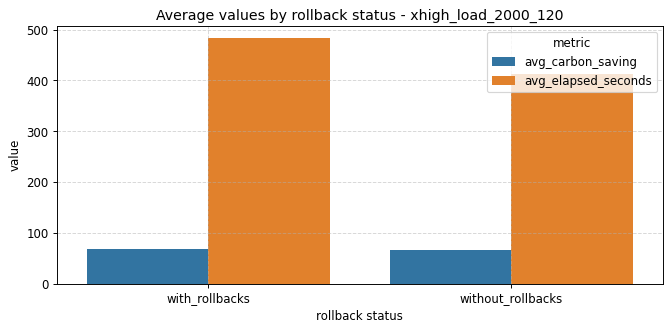

In [36]:
# Pick one scenario to analyze
# scenario = "high_load_1500_92"
scenario = "xhigh_load_2000_120"

scenario_df = df[df["scenario_id"] == scenario].copy()

# Keep only meaningful columns for the analysis
cols = [
    "scenario_id",
    "batch_size",
    "parallelism",
    "policy",
    "carbon_saving",
    "elapsed_seconds",
    "total_RBs",
    "RB_max_consecutive",
    "final_global_error",
]
scenario_df = scenario_df[cols].copy()

# Top 5 runs by carbon saving
top5 = scenario_df.nlargest(5, "carbon_saving").copy()
# For better readability, display the exact top 5 rows
print(f"Top 5 runs for {scenario} by carbon_saving:")
display(top5[["batch_size", "parallelism", "policy", "carbon_saving", "elapsed_seconds", "total_RBs"]])

# Check how many of the top 5 have total_RBs > 0 (spoiler: None)
num_with_rollbacks = int((top5["total_RBs"] > 0).sum())
print(f"Top 5 runs with total_RBs > 0: {num_with_rollbacks} / 5")

# Compare averages for runs with and without rollbacks
with_rollbacks = scenario_df[scenario_df["total_RBs"] > 0].copy()
without_rollbacks = scenario_df[scenario_df["total_RBs"] == 0].copy()

summary = {
    "group": ["with_rollbacks", "without_rollbacks"],
    "runs": [
        len(with_rollbacks),
        len(without_rollbacks),
    ],
    "avg_carbon_saving": [
        with_rollbacks["carbon_saving"].mean() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].mean() if len(without_rollbacks) else None,
    ],
    "avg_elapsed_seconds": [
        with_rollbacks["elapsed_seconds"].mean() if len(with_rollbacks) else None,
        without_rollbacks["elapsed_seconds"].mean() if len(without_rollbacks) else None,
    ],
    "min_carbon_saving": [
        with_rollbacks["carbon_saving"].min() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].min() if len(without_rollbacks) else None,
    ],
    "max_carbon_saving": [
        with_rollbacks["carbon_saving"].max() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].max() if len(without_rollbacks) else None,
    ],
}

summary_df = pd.DataFrame(summary)
display(summary_df)

# Optional plot: compare mean carbon_saving and elapsed_seconds for groups
summary_plot = summary_df[["group", "avg_carbon_saving", "avg_elapsed_seconds"]].copy()
summary_plot = summary_plot.melt(
    id_vars="group",
    value_vars=["avg_carbon_saving", "avg_elapsed_seconds"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(8, 4))
sns.barplot(data=summary_plot, x="group", y="value", hue="metric")
plt.title(f"Average values by rollback status - {scenario}")
plt.ylabel("value")
plt.xlabel("rollback status")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Rollback not so useful
Rollbacks ensure a higher minimum carbon saving (63% vs 56%), but the average carbon saving is almost the same (67% vs 66%). The elapsed time instead is higher, 1.16x times slower for runs with rollbacks than for runs without rollbacks (482s vs 412s for high_load_2000_120).


Takeaway message: <u>Rollbacks can probably be avoided.</u>



## Planet vs Profit
`test2` runs have the error threshold varying in `(3.0,3.5,4.0,4.5)` to observe how much the error threshold affects the carbon saving. The results show that the error threshold has a significant impact on the carbon saving, with higher thresholds yielding considerably higher carbon savings.

In fact, the intuition is that simply relying on time shifting does not yield much carbon saving (if any), and that the main source of carbon saving is exploiting the error threshold, but we'll discuss this in more detail later.

Note that here we are examining also **offline policies**. Even if not applicable to real-time scenarios, they can provide some numbers for comparison and help understanding the potential carbon savings under ideal conditions.

policy               carryover  offline_ant_colony  offline_bandit  \
error_threshold_bin                                                  
3.0                     51.396               54.64           45.21   
3.5                     59.356               61.75           51.72   
4.0                     67.528               69.94           62.24   
4.5                     75.394               77.04           69.68   

policy               offline_greedy_cheapest  online_ant_colony  \
error_threshold_bin                                               
3.0                                    54.81          38.340000   
3.5                                    61.74          50.070000   
4.0                                    68.55          61.364444   
4.5                                    75.61          71.123333   

policy               online_bandit  online_greedy_singleton  
error_threshold_bin                                          
3.0                      41.453333                    42.83  
3.5                      49.133333                    53.42  
4.0                      60.494444                    66.35  
4.5                      68.850000                    75.39

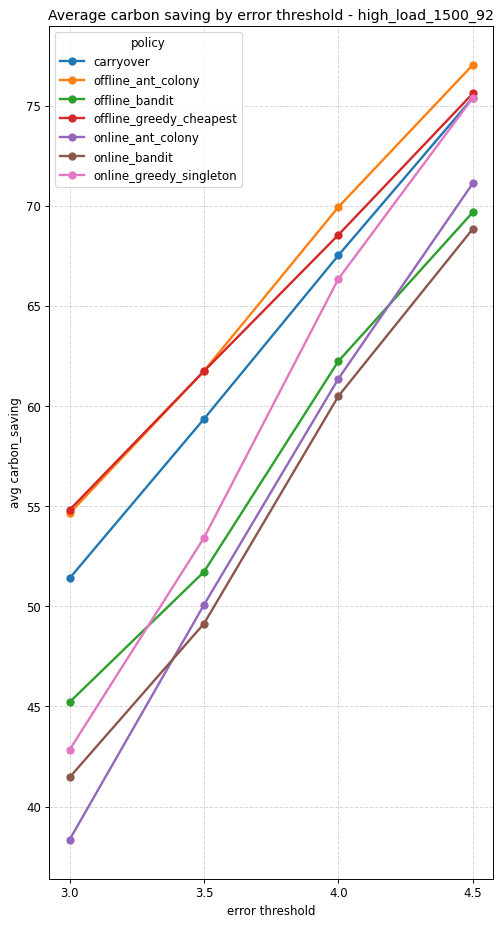

In [37]:
'''
There is no explicit threshold field in the dataset; we infer it from the final_global_error using binning, knowing that the error threshold is in (3.0, 3.5, 4.0, 4.5), and that the solver always ends up very close to the threshold used.
Consider that final_global_error should be close to the error threshold used, but may differ of a few percents (e.g. if the threshold is 4.0, final_global_err may be 3.98).
'''

df_2 = df_all[df_all["path"].str.contains("cfg_test2")].copy()

# Pick a scenario to analyze
scenario = "high_load_1500_92"
# scenario = "xhigh_load_2000_120"

scenario_df = df_2[df_2["scenario_id"] == scenario].copy()
scenario_df["final_global_error"] = pd.to_numeric(scenario_df["final_global_error"], errors="coerce")
scenario_df = scenario_df.dropna(subset=["final_global_error", "carbon_saving", "policy"]).copy()

# Error thresholds used in the experiment
thresholds = [3.0, 3.5, 4.0, 4.5]
# Use a small bin around each threshold to account for small numerical differences
bins = [2.75, 3.25, 3.75, 4.25, 4.75]
labels = [3.0, 3.5, 4.0, 4.5]

scenario_df["error_threshold_bin"] = pd.cut(
    scenario_df["final_global_error"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

summary = (
    scenario_df
    .dropna(subset=["error_threshold_bin"])
    .groupby(["policy", "error_threshold_bin"], as_index=False,observed=False)["carbon_saving"]
    .mean()
    .rename(columns={"carbon_saving": "avg_carbon_saving"})
    .sort_values(["error_threshold_bin", "policy"])
    .reset_index(drop=True)
)

# display(summary)

# Pivot table for easier comparison
pivot = (
    summary
    .pivot(index="error_threshold_bin", columns="policy", values="avg_carbon_saving")
    .reindex(labels)
)
display(pivot)

# Plot: average carbon saving by error threshold, one line per infeasibility mode
plt.figure(figsize=(6, 11))
for mode in pivot.columns:
    plt.plot(pivot.index.astype(float), pivot[mode].values, marker="o", linewidth=2, label=mode)

plt.title(f"Average carbon saving by error threshold - {scenario}")
plt.xlabel("error threshold")
plt.ylabel("avg carbon_saving")
plt.xticks(thresholds)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="policy")
plt.tight_layout()
plt.show()

### Considerations

Varying the threshold has significant impact on the carbon saving. This is also due to the strong gap between the exec time of the three available flavours (10s,30s,60s). If we had more similar execution times, the impact of the threshold might be less pronounced, but still present.

Aside from this, we can (happily😊) observe that Carbonshift is second only to two offline policies. 

## Relying only on shifting

So, to prove the intuition mentioned above, let's limit the **flavours** to only the most accurate one, making the time shift the only possible source of carbon saving.


What is expected is that if the sinusoidal load pattern is in phase with the carbon intensity (high number of requests is received in the periods of high carbon intensity), then the carbon saving from time shifting should be significant, while if it is opposed in phase, then the carbon saving should be negligible, since the baseline execution would already be close to the optimal scheduling, and the shifting would not provide much additional benefit.

CI patterna and input request pattern in `test3` have phase opposition, in `test4` are in phase, and `test5` have phase 25% disalignment (50% disalignment would be phase inversion).



### About cap levels
Clearly, cap levels interact with the input request pattern and the CI pattern. In `test4` (phase opposition), we will observe how different cap levels affect the carbon savings and the scheduling behavior.


### Possible high load on the last slot
If the CI has a valley in the last slot, requests might tend to accumulate there:
- having a valley in the last slot means that before there is a peak
- the scheduler will avoid scheduling many requests in the peak, preferring the descending CI trend up to the last slot
- since in the simulation environment the scheduler only has visibility up to the last slot, this one becomes a natural accumulation point for requests, because, as time slots progress, the scheduler has fewer options for placing requests, with the last being the cheapest (in terms of original CI).
- upon reaching the last slot, the scheduler has no other choice but to schedule all remaining requests in that slot. It happens similarly also for the last few slots, but the effect is more pronounced for the last one. 


We could choose, for testing purposes, to let the scheduler schedule requests in slots beyond the last slot and leave them out of the evaluation. This would better mimick a real-world scenario where there is no "last slot" and later on only a window is evaluated, however this would lead to have, at each test execution, a slightly different amount of requests to be evaluated overall.\
In both cases we have to deal with a little anomaly, so we leave it as it is.


<small><small>
Actually a third option would be to extend the simulation to another 14 slots (86 slots in total), and later cut them out to get 72 slots, but these tests take quite some time as they are and I thought about this only recently, so I decided not to pursue it for now to avoid re-running lengthy simulations. We could even extend it further more to cut out the first few slots as well, which are scarsely used.\
I think that for the purposes of these tests, the current approach is sufficient and the minor anomaly at the last slot can be tolerated.
</small></small> 

#### test3 - phase opposition
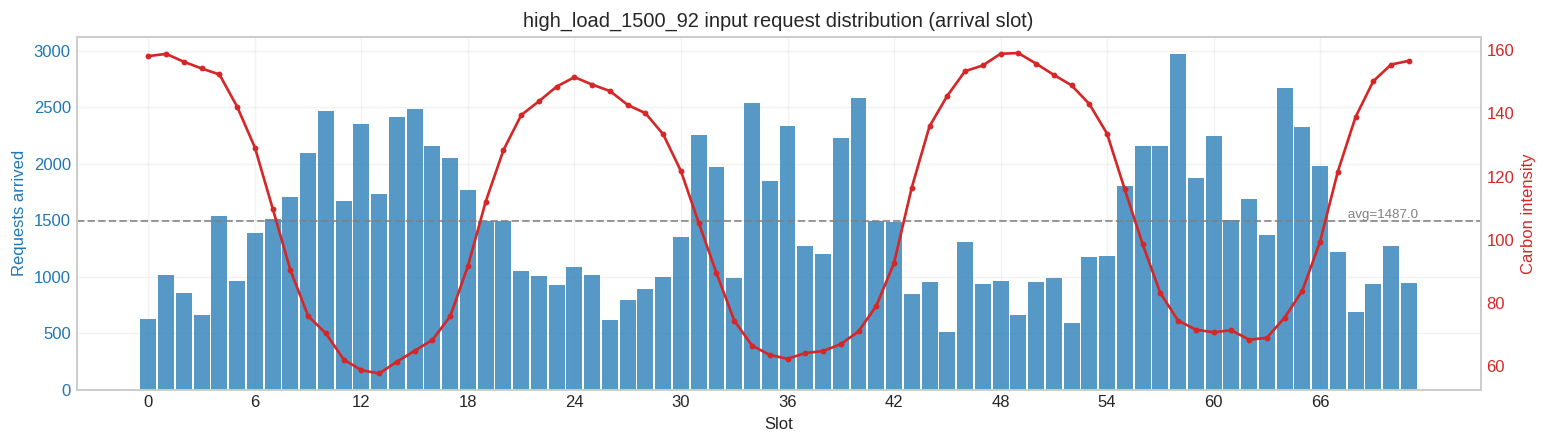
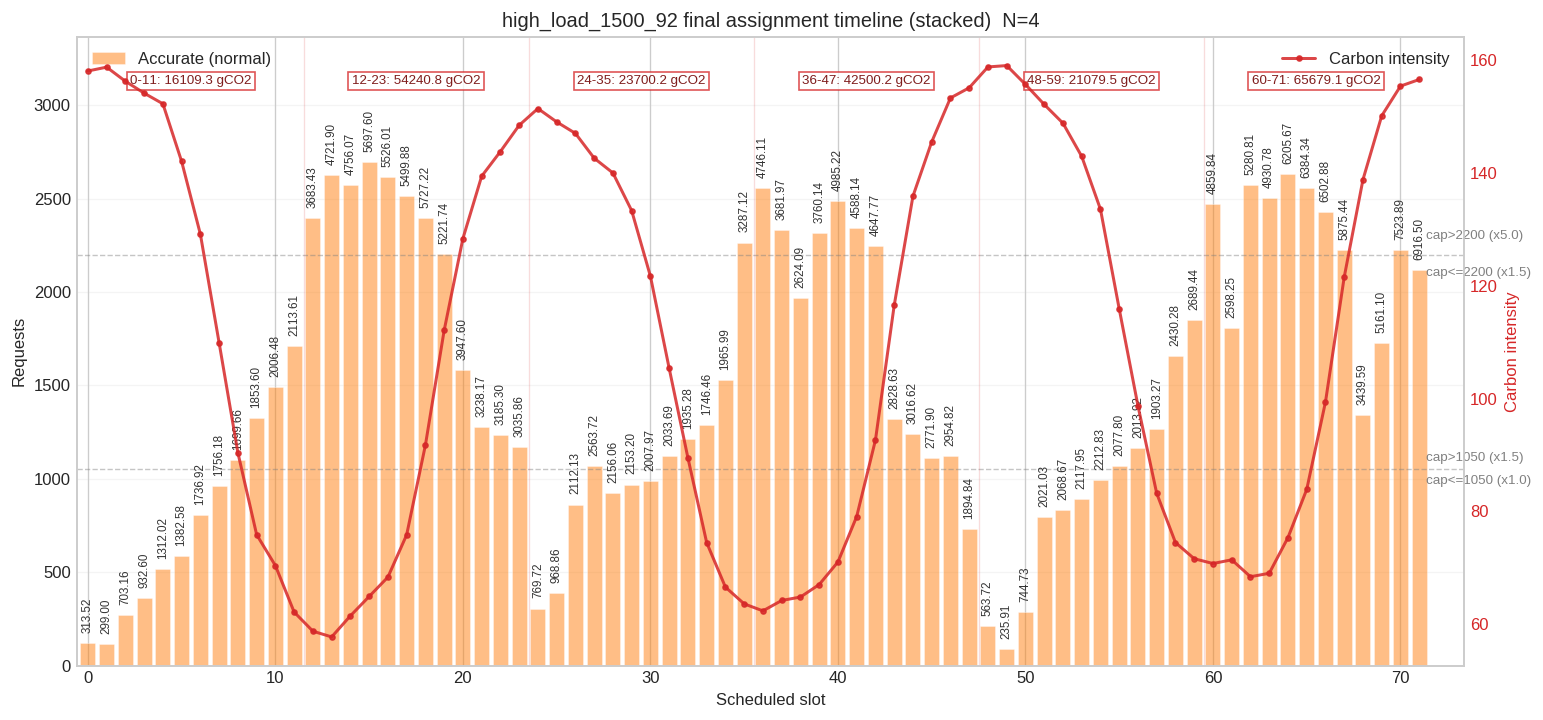

#### test4 - in phase
Below are images displaying different combinations of cap levels for the scenarios high_load_1500_92 and xhigh_load_2000_120. Cap levels are indicated in grey on the right of the orange assignment plots. 
These images help visualize how different capacity levels impact the outcome.

Below the plots there is a table summarizing the carbon savings for each scenario and cap level combination.
<!-- 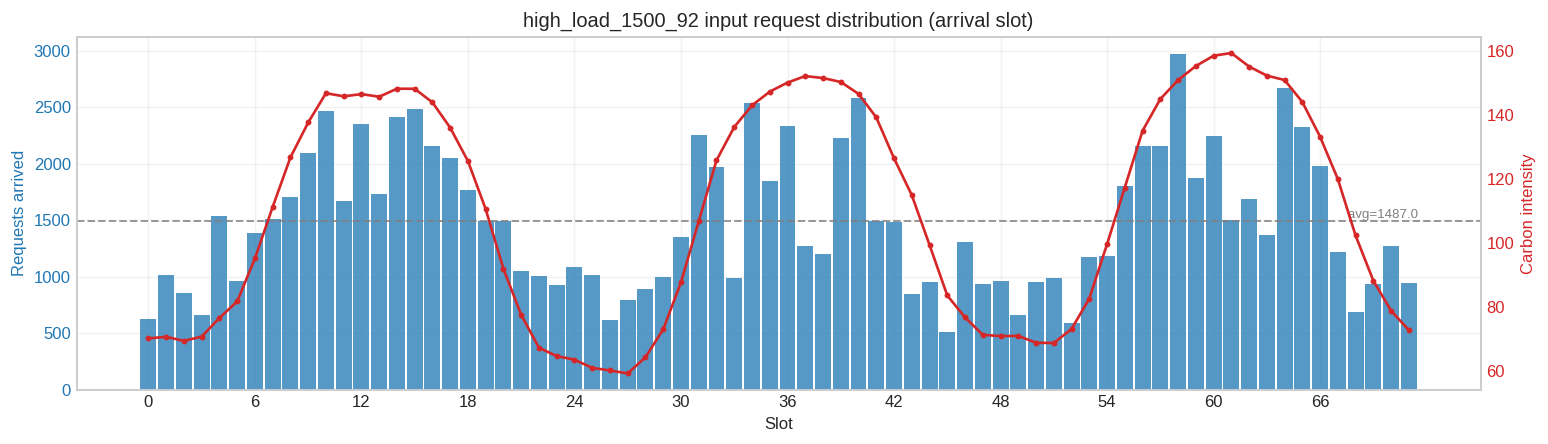 -->
<!-- 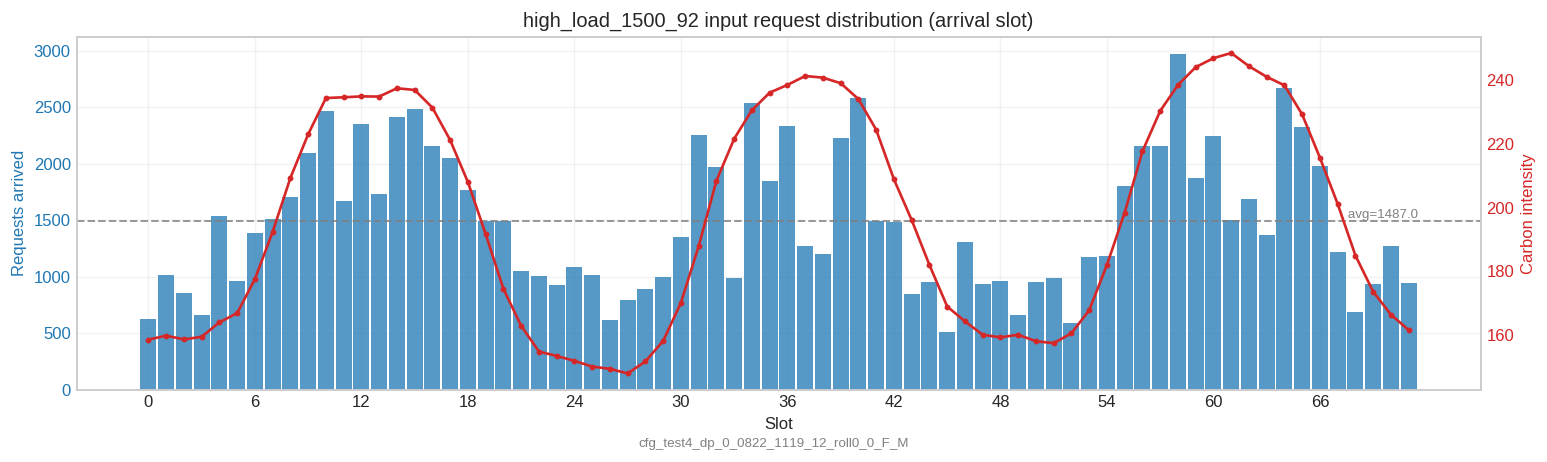 -->
##### Scenario high_load_1500_92
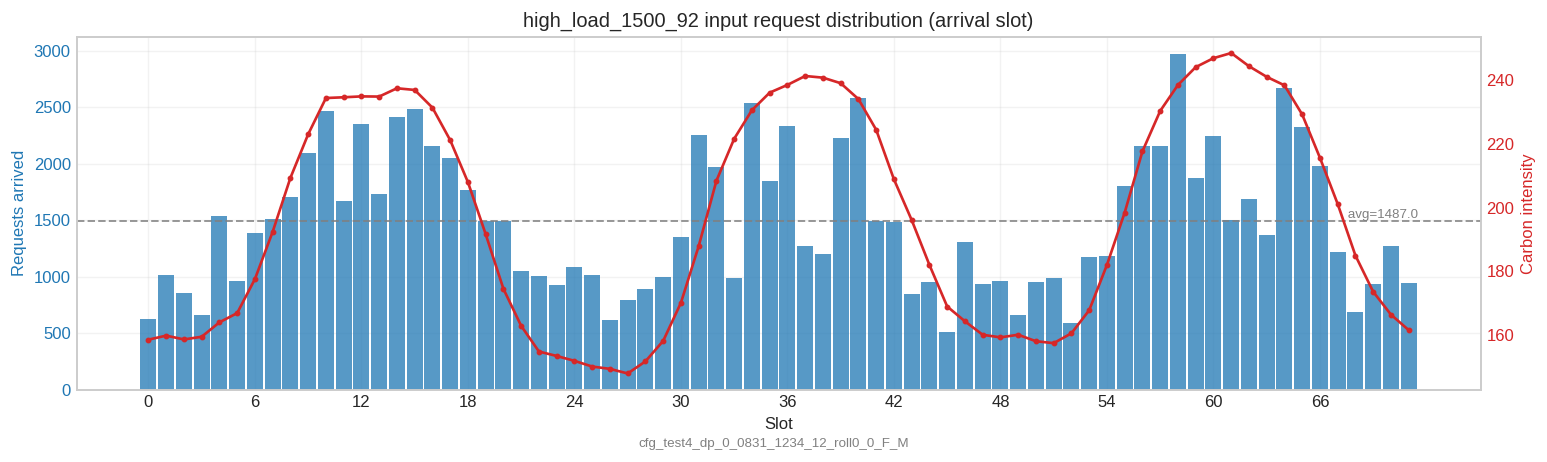
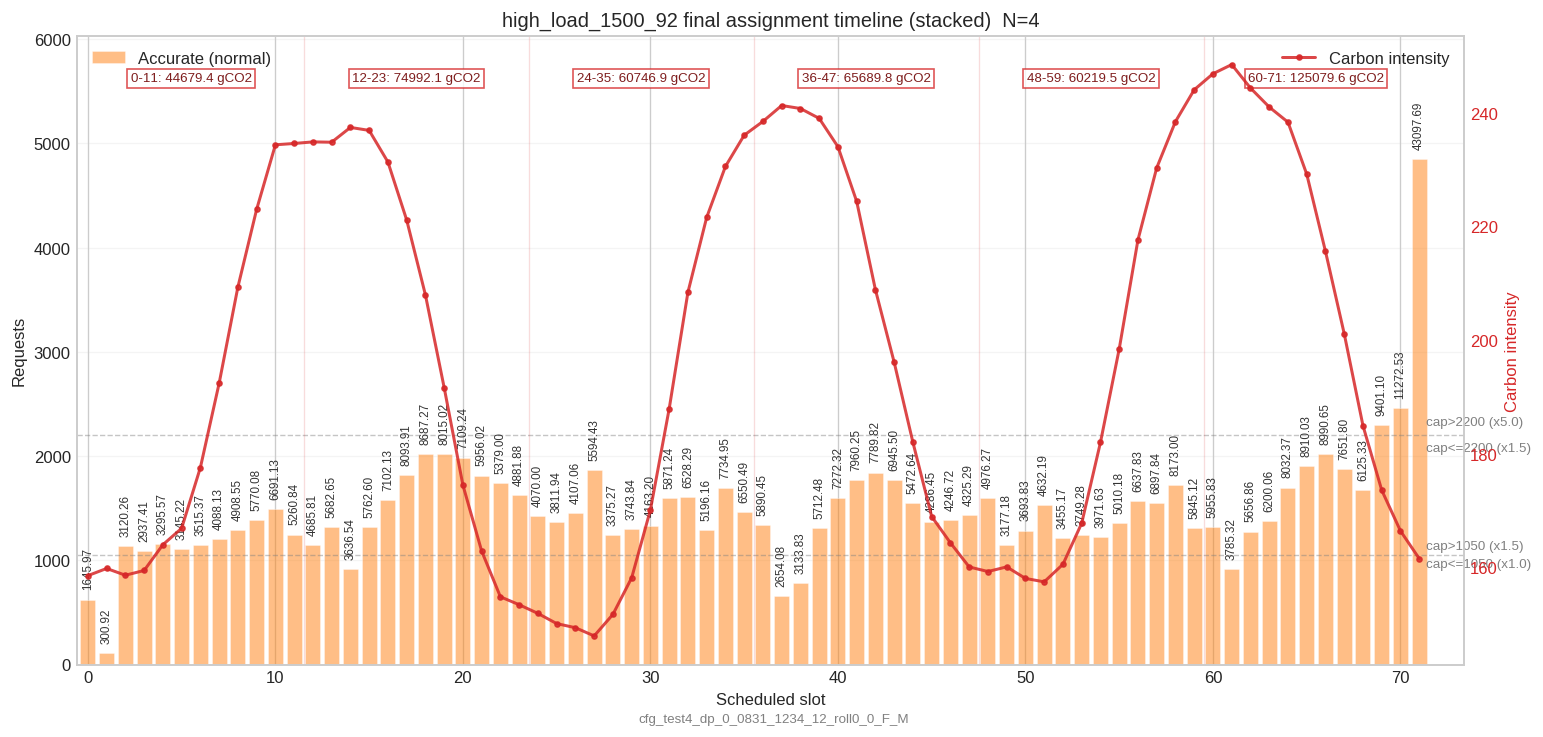
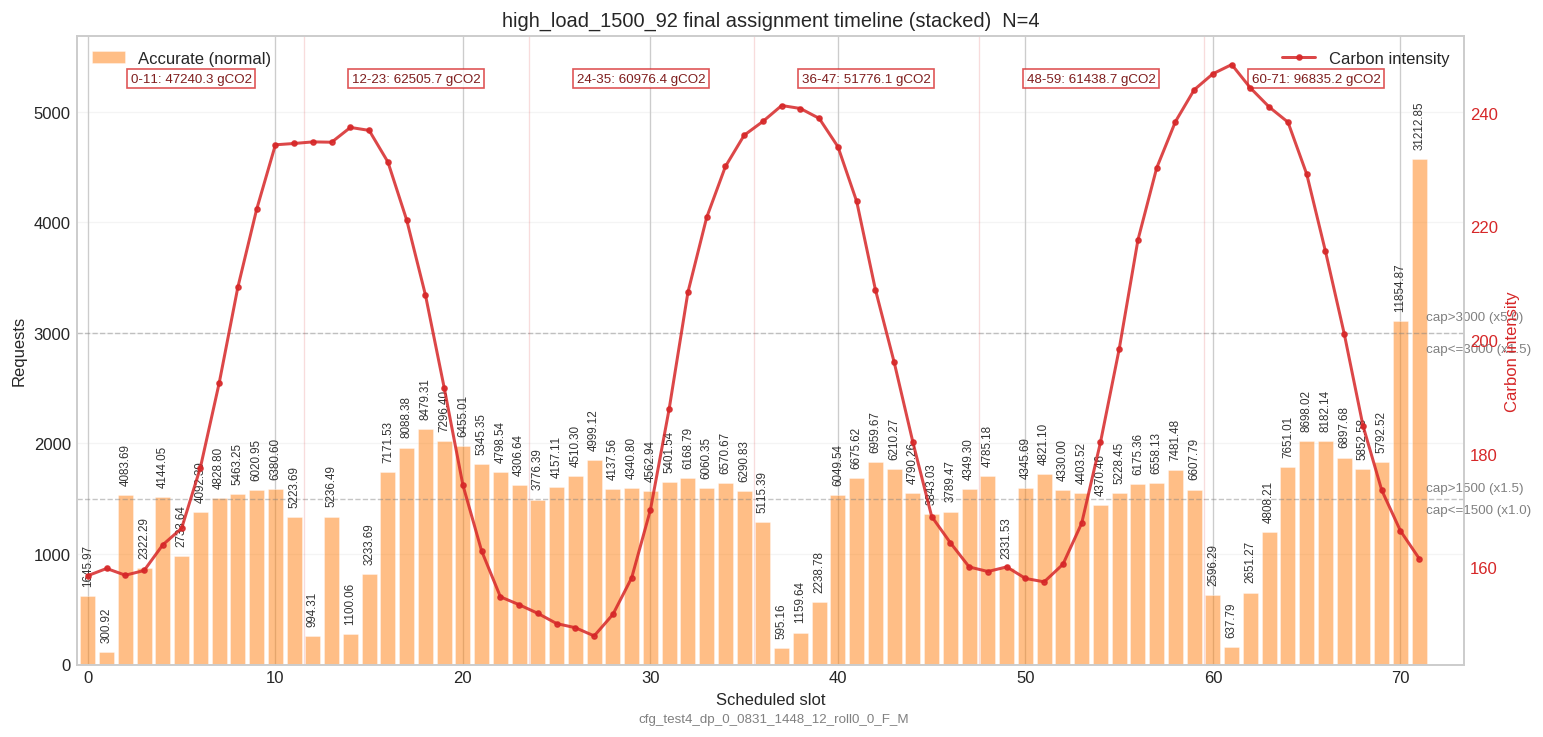
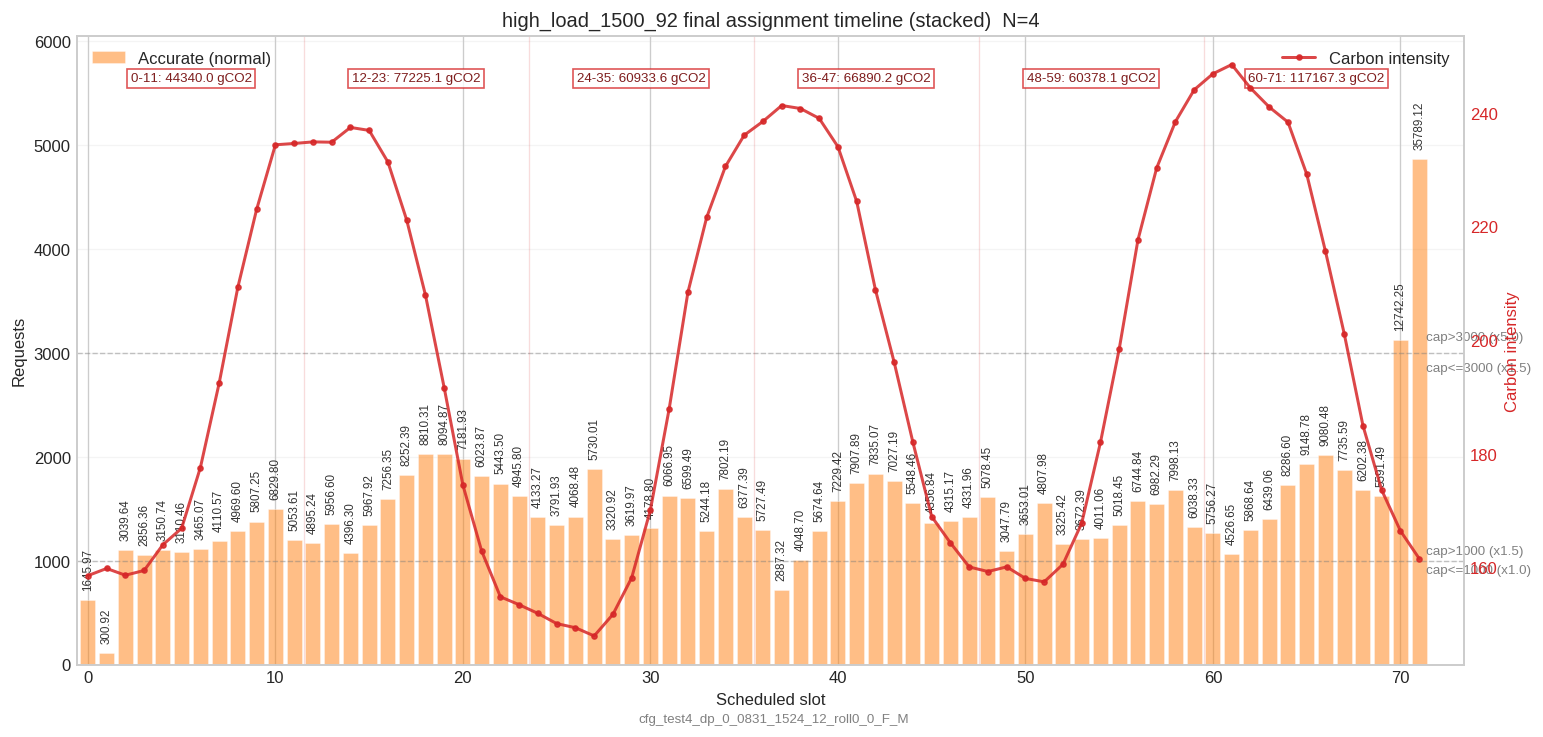
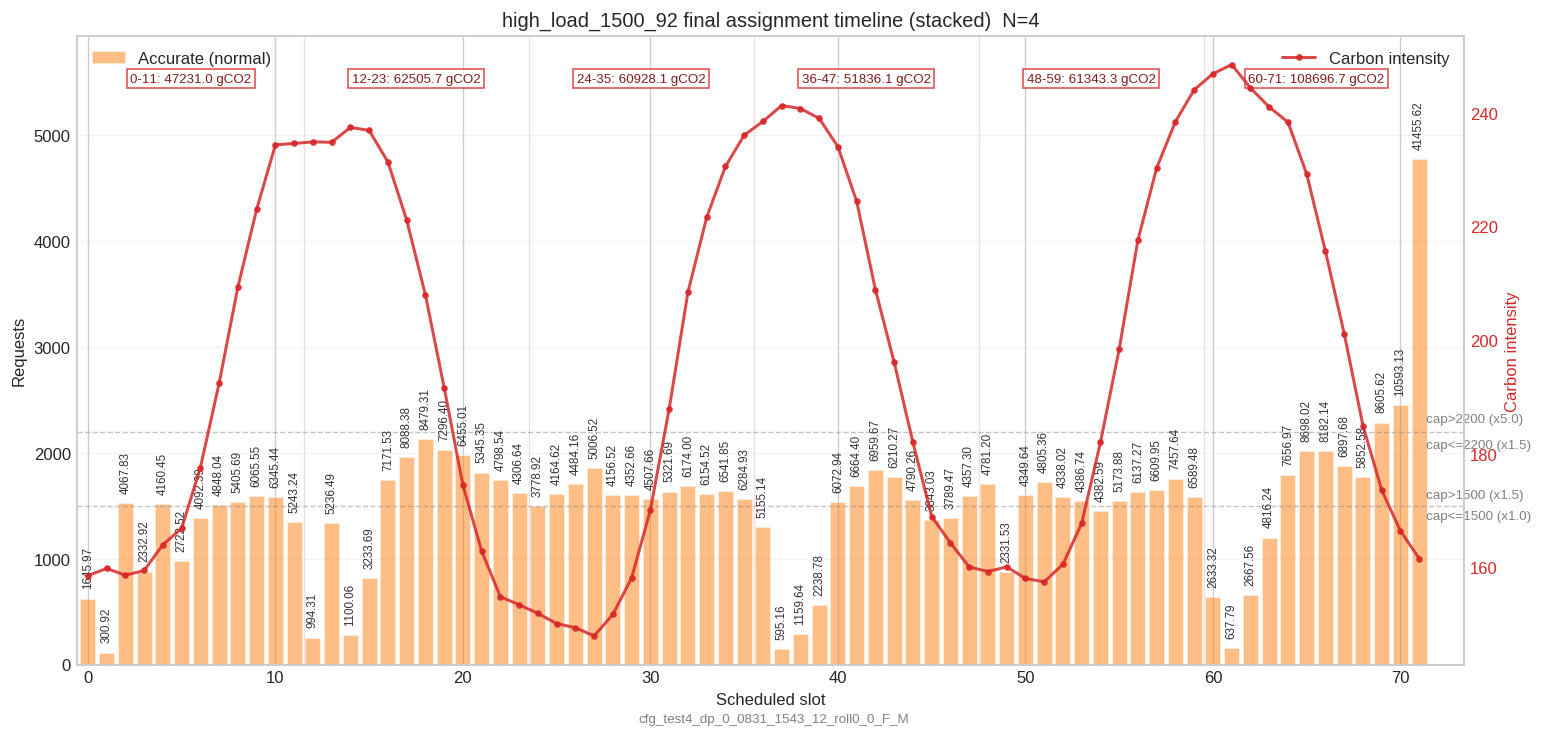

<!-- 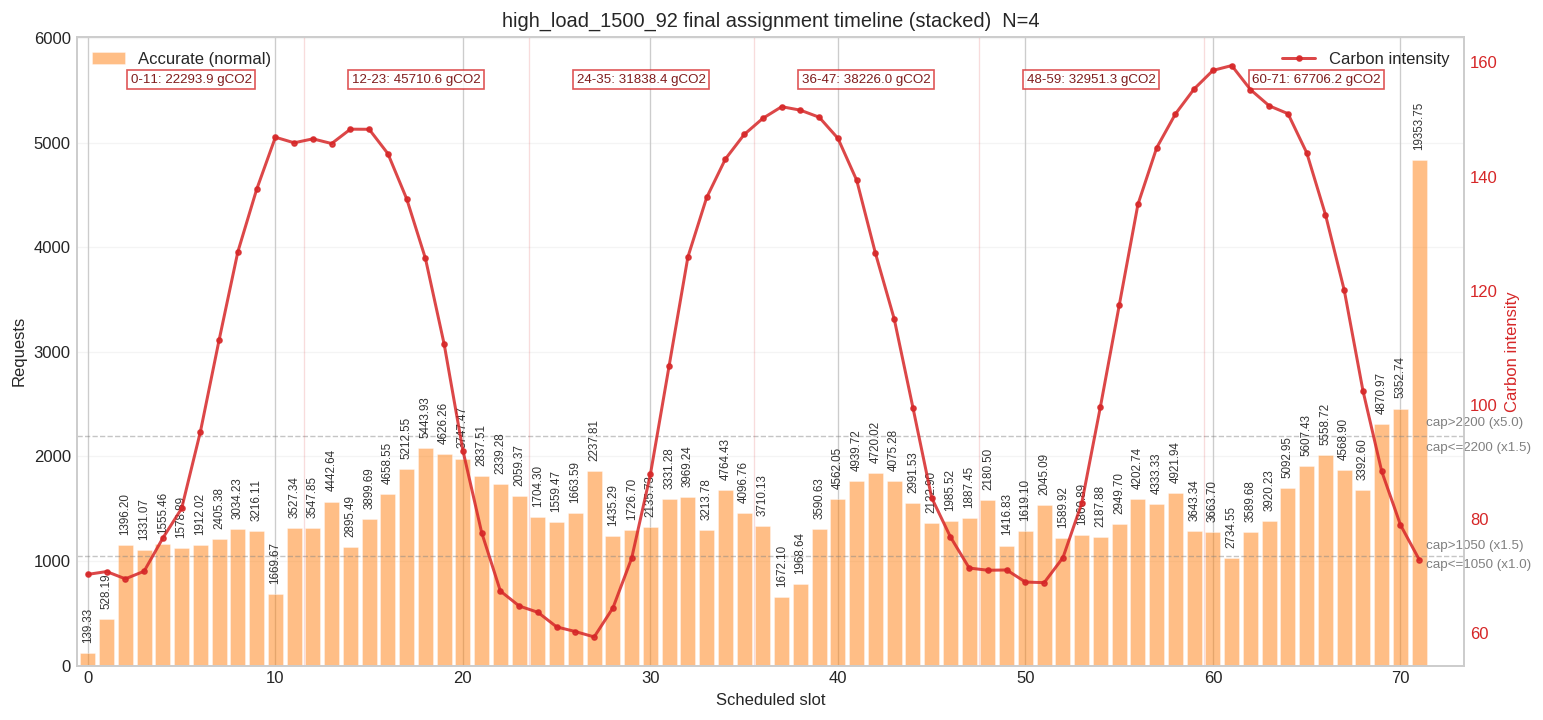 -->
<!-- 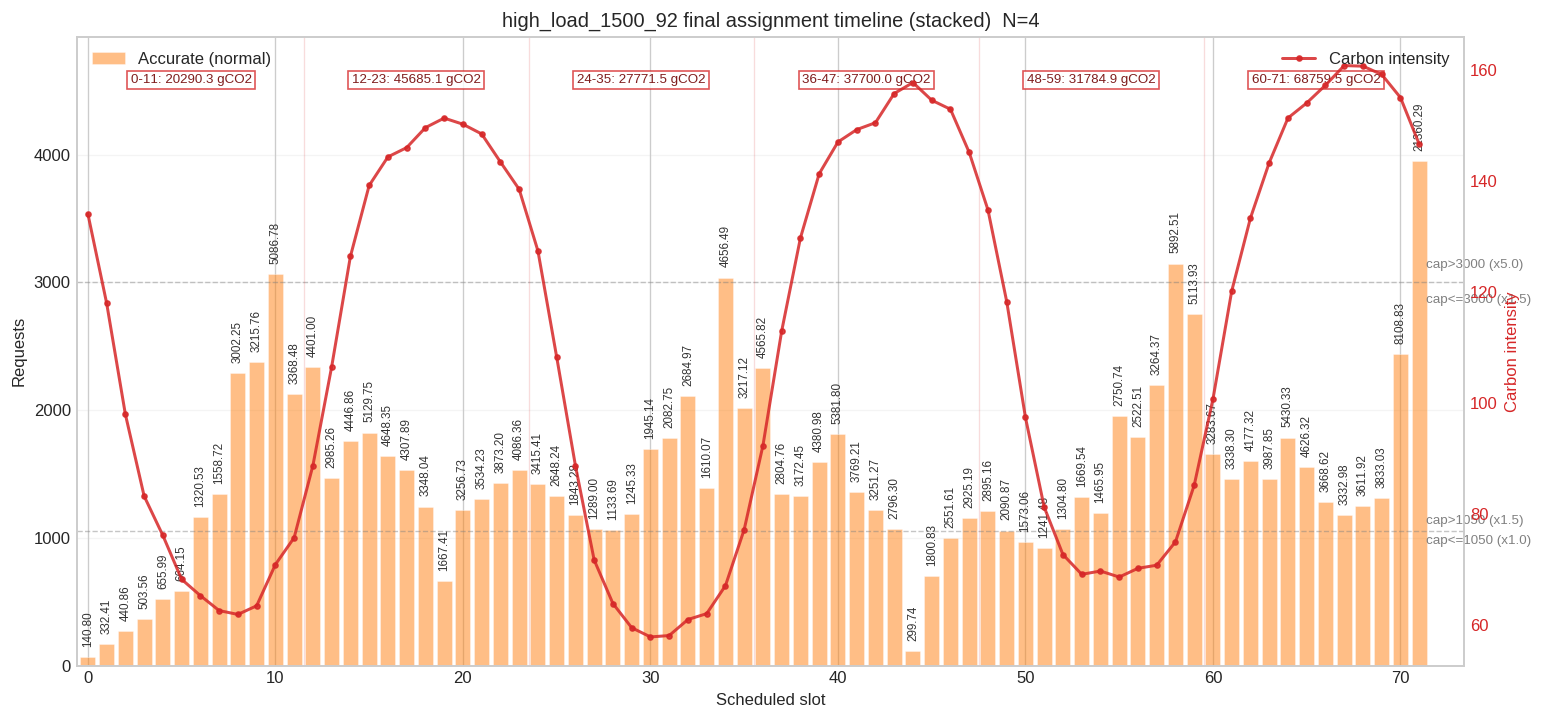 -->
##### Scenario xhigh_load_2000_120
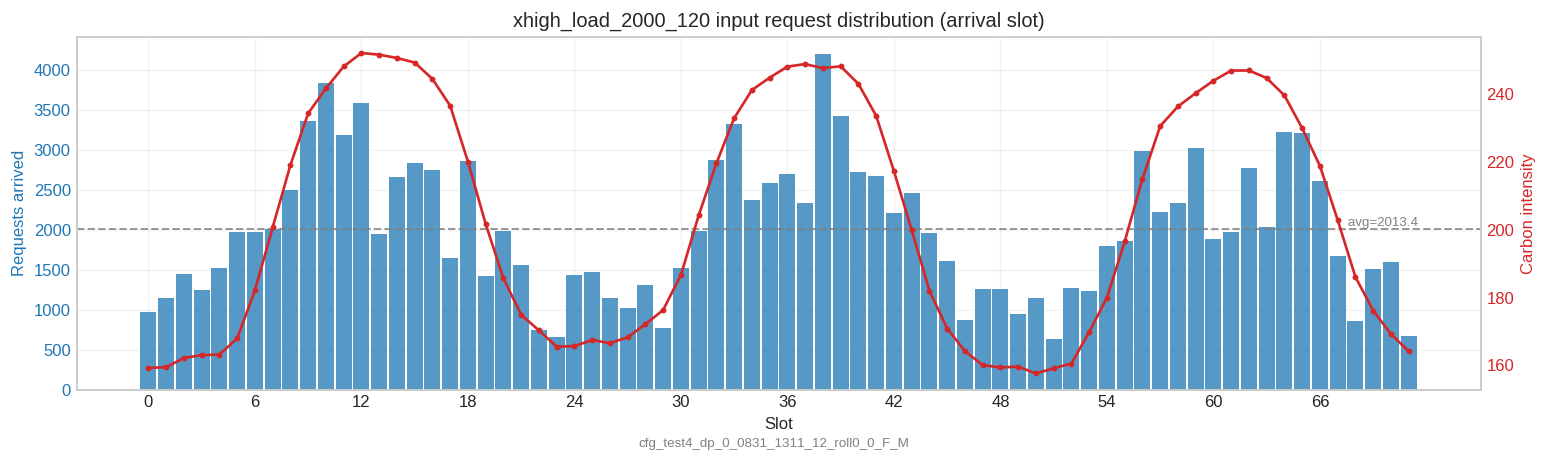
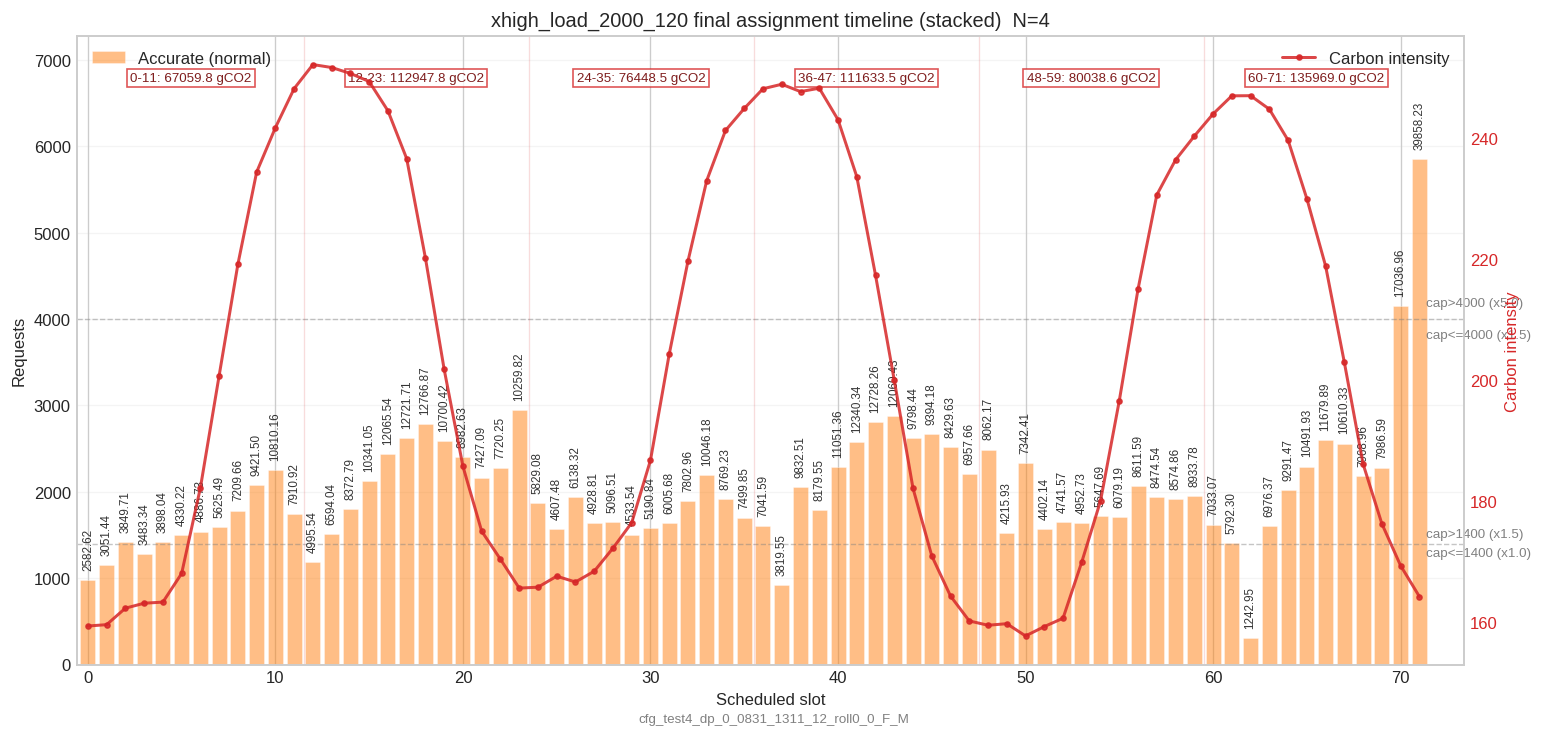
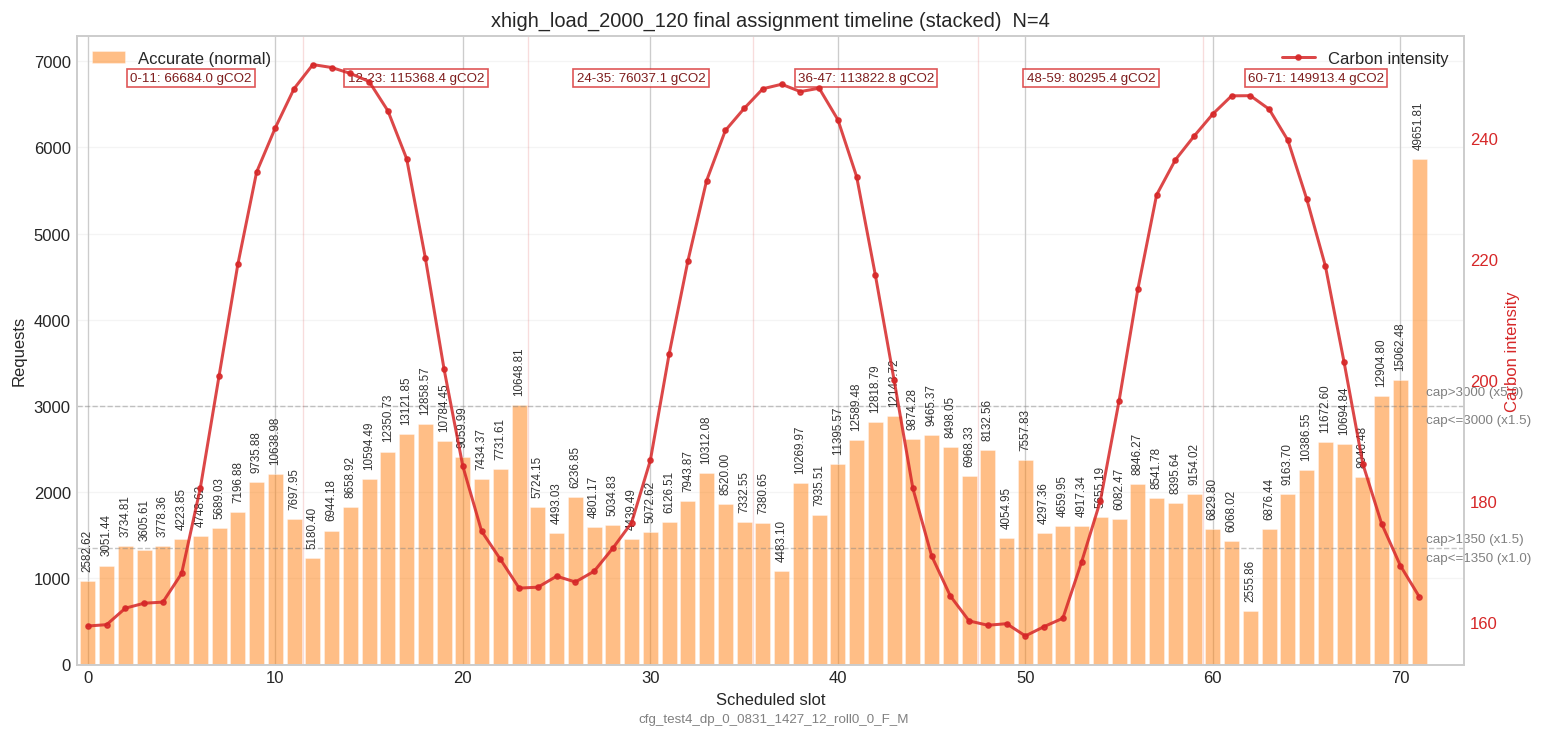
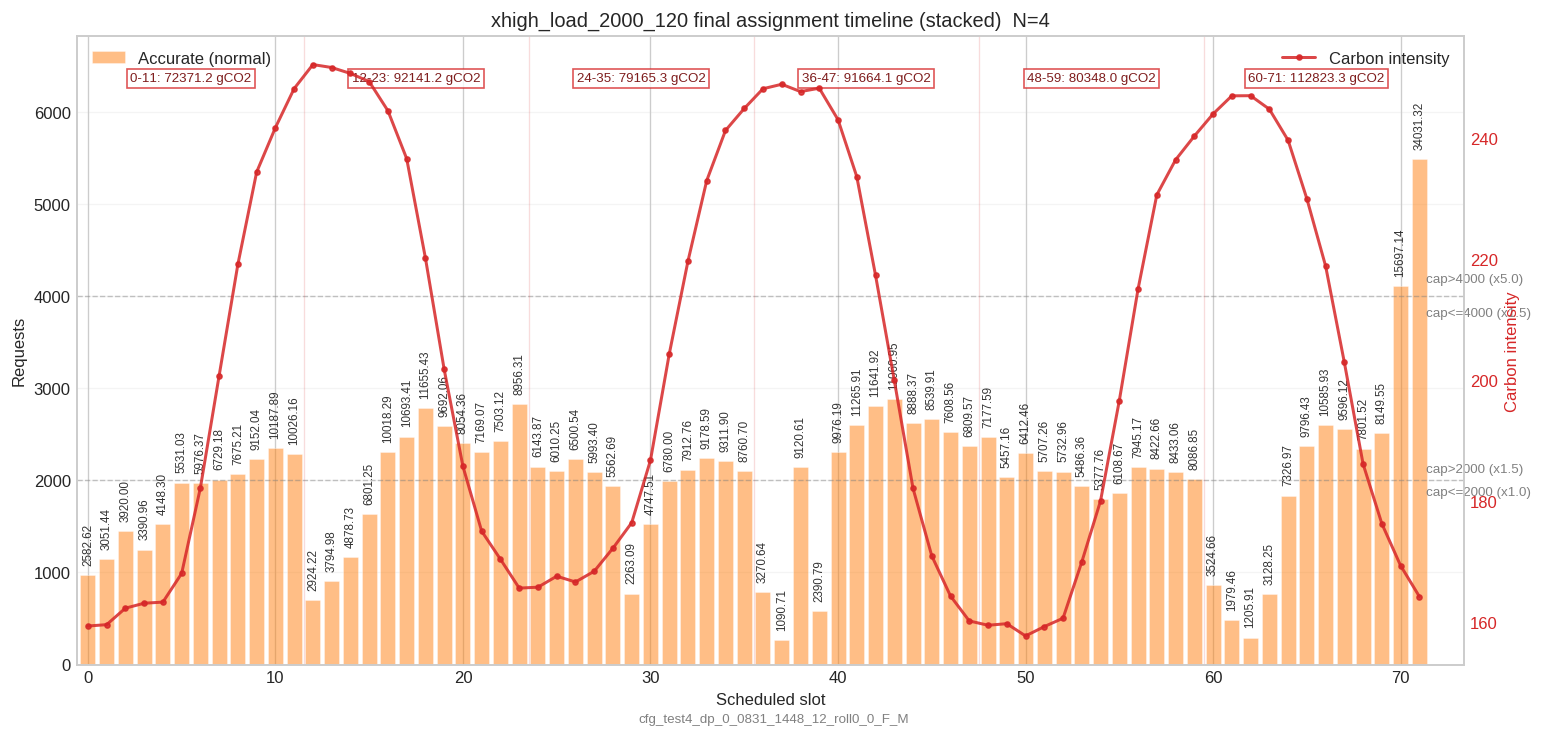
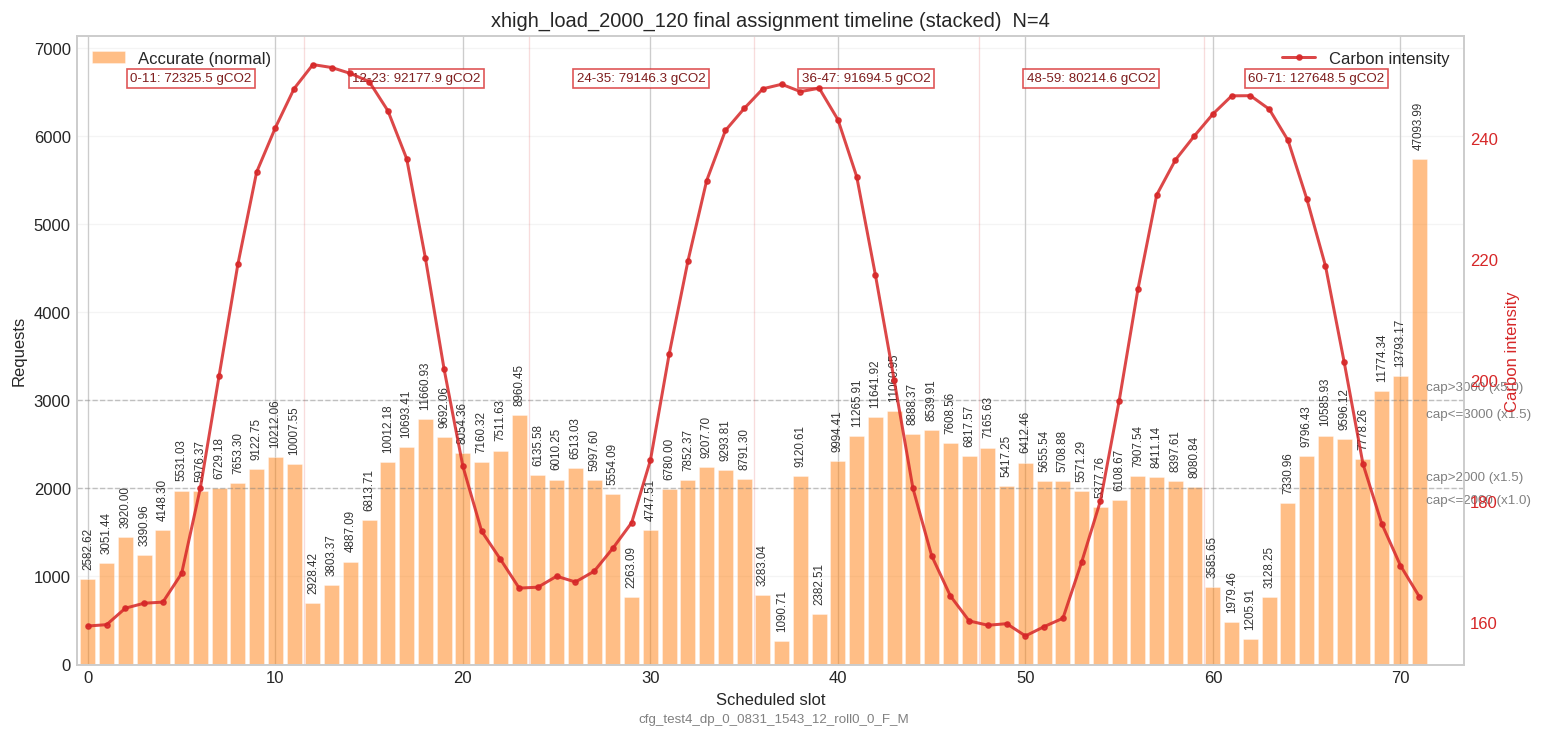

##### Summary
| Scenario | CAP levels | Carbon Saving |
|----------|------------|----------------|
| high_load_1500_92 | (1050,2200) | 10.77 |
| high_load_1500_92 | (1500,3000) | 6.2 |
| high_load_1500_92 | (1000,3000) | 3.67 |
| high_load_1500_92 | **(1500,2200)** | **12.91** |
| xhigh_load_2000_120 | (1400,4000) | 6.29 |
| xhigh_load_2000_120 | (1350,3000) | 12.47 |
| xhigh_load_2000_120 | (2000,4000) | 8.12 |
| xhigh_load_2000_120 | **(2000,3000)** | **14.46** |


Note that for the two scenarios, input requests range from 500 to 3000 and 4000 respectively.

Shifting provides best saving results when the gap between two cap levels is narrower,the first matching the average input request rate and the second being below the peaks.
Setting the second cap level higher makes shifting less effective in achieving carbon savings since it (almost) never happens that the input requests exceed this higher cap level, lowering the baseline cost .\
Setting it lower instead, aside from increasing the baseline cost, forces carbonshift to optimize shifting more aggressively to stay within the cap.\
Having the first cap level below the average input request reduces room for shifting, as in most slots the requests will exceed this cap.\



#### test5 - 25% disalignment
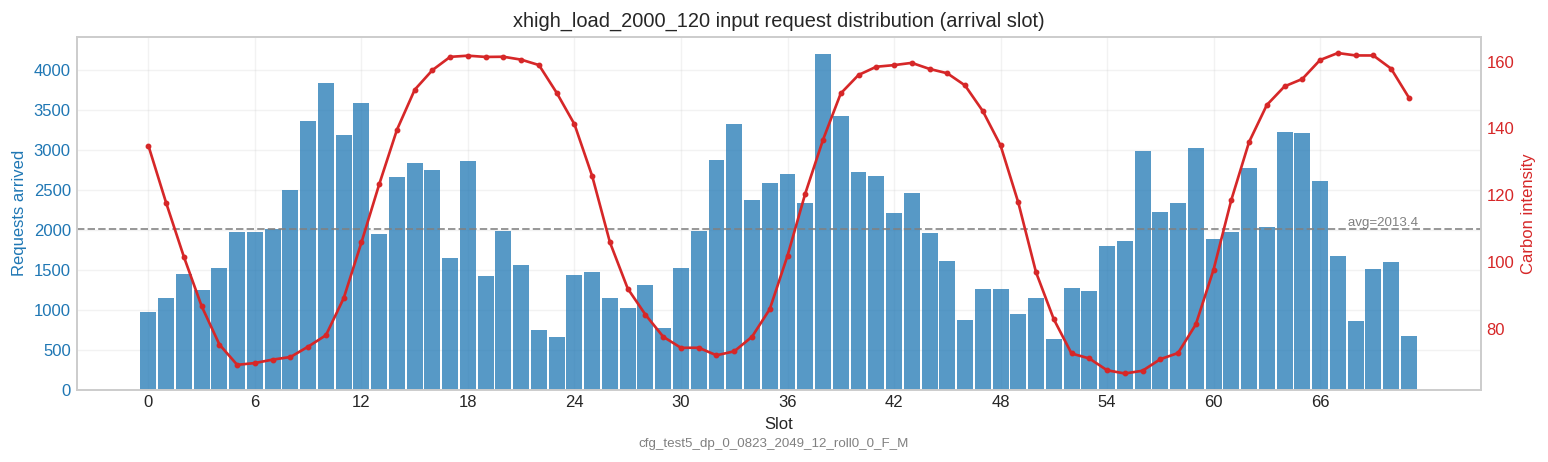
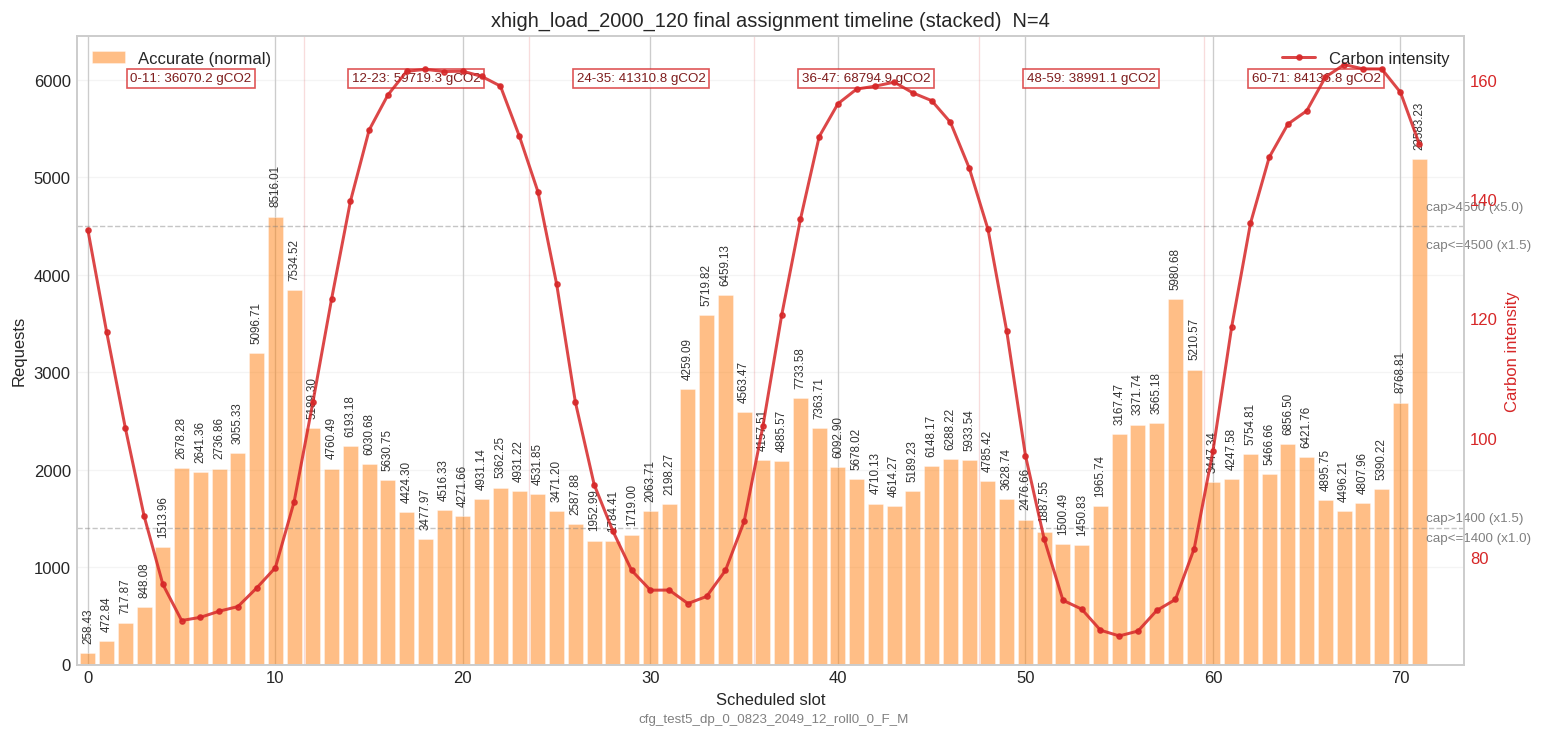

Here saving is pretty limited, ranging from negative to low positive values, depending on the scenario.

In [38]:
df_test5 = df_all[df_all["path"].str.contains("cfg_test5")].copy()
# display(df_test5)

# get average, min, max carbon_saving for df_test5 for each scenario
df_test5.groupby("scenario_id")["carbon_saving"].agg(["mean", "min", "max"])

mean   min   max
scenario_id                           
high_load_1500_92   -1.570 -2.44  1.39
xhigh_load_2000_120  1.504  0.43  2.94

## Evaluating different cap levels across a more comprehensive test suite

Let's see how the different cap levels affect the results across a more complete test suite, including different policies.

### Considerations
**Phase opposition** 
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 8    | 1500/3000  | 2000/4000  | Accurate |
| 9    | 1500/3000  | 2000/4000  | All      |
| 10   | 1000/3000  | 1350/4000  | All      |
| 11   | 1500/2200  | 2000/3000  | Accurate |
| 12   | 1500/2200  | 2000/3000  | All      |

**In phase** 
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 13   | ❌         | 2000/4000  | All      |
| 14   | ❌         | 2000/3000  | All      |


We will now analyze the impact of different cap levels on an ad-hoc test suite.
Tables will be provided grouping on the **infeasibility mode**.

In [39]:
# 8 and 9 have cap levels set at 1500/3000 and 2000/4000
# 8 has only Accurate flavour
df_test8 = df_all[df_all["path"].str.contains("cfg_test8")].copy()
# 9 has all flavours
df_test9 = df_all[df_all["path"].str.contains("cfg_test9")].copy()
# 10 has cap levels set at 1000/3000 and 1350/4000
df_test10 = df_all[df_all["path"].str.contains("cfg_test10")].copy()
# 11 has cap levels set at 1500/2200 and 2000/3000 and only accurate flavour
df_test11 = df_all[df_all["path"].str.contains("cfg_test11")].copy()
# 12 has cap levels set at 1500/2200 and 2000/3000
df_test12 = df_all[df_all["path"].str.contains("cfg_test12")].copy()

# 13 has cap level at 2000/4000
df_test13 = df_all[df_all["path"].str.contains("cfg_test13")].copy()
# 14 has cap level at 2000/3000
df_test14 = df_all[df_all["path"].str.contains("cfg_test14")].copy()

# build df_tests adding a column "testID"
df_test8["testID"] = "cfg_test08"
df_test9["testID"] = "cfg_test09"
df_test10["testID"] = "cfg_test10"
df_test11["testID"] = "cfg_test11"
df_test12["testID"] = "cfg_test12"
df_test13["testID"] = "cfg_test13"
df_test14["testID"] = "cfg_test14"

# add "caps" column indicating cap level for each test, depending on the scenario
df_test8["caps"] = df_test8.apply(lambda row: "1500/3000" if row["scenario_id"] == "high_load_1500_92" else "2000/4000", axis=1)
df_test9["caps"] = df_test9.apply(lambda row: "1500/3000" if row["scenario_id"] == "high_load_1500_92" else "2000/4000", axis=1)
df_test10["caps"] = df_test10.apply(lambda row: "1000/3000" if row["scenario_id"] == "high_load_1000_92" else "1350/4000", axis=1)
df_test11["caps"] = df_test11.apply(lambda row: "1500/2200" if row["scenario_id"] == "high_load_1500_92" else "2000/3000", axis=1)
df_test12["caps"] = df_test12.apply(lambda row: "1500/2200" if row["scenario_id"] == "high_load_1500_92" else "2000/3000", axis=1)
df_test13["caps"] = df_test13.apply(lambda row: "2000/4000", axis=1)
df_test14["caps"] = df_test14.apply(lambda row: "2000/3000", axis=1)


# Exclude test13 and 14 for now, since they only have scenario xhigh_2000
df_tests = pd.concat([df_test8, df_test9, df_test10, df_test11, df_test12], ignore_index=True)


# filter df_tests to include only runs where infeasibility mode is "carryover"
df_tests_carryover = df_tests[df_tests["policy"] == "carryover"].copy()
# display the first few rows of the filtered dataframe 
df_tests_carryover.head()
 
'''
Filter to get only batch size == 4 for carryover
We want a proper summary. For each testID, each infeasibility mode, and each scenario (it's two of them), we want to get average/stddev carbon cost, average/stddev carbon saving, average/min/max elapsed_seconds
'''
df_tests_all_and_batch4 = df_tests[(df_tests["batch_size"] == 4) | (df_tests["policy"] != "carryover")].copy()
# sort by testID, policy, and scenario_id
df_tests_all_and_batch4.sort_values(by=["testID", "policy", "caps", "scenario_id"], inplace=True)

df_tests_batch4 = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"] == "carryover"].copy()
df_tests_online = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"].str.contains("online_bandit|online_ant")].copy()
df_tests_offline = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"].str.contains("offline_bandit|offline_ant")].copy()
df_tests_greedy = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"].str.contains("greedy")].copy()

# def aggregation function for summarizing the dataframe
def aggregate_summary(df):
    return df.groupby(["testID", "policy", "caps", "scenario_id"]).agg(
        avg_carbon_cost=("carbon_cost", "mean"),
        std_carbon_cost=("carbon_cost", "std"),
        avg_carbon_saving=("carbon_saving", "mean"),
        max_carbon_saving=("carbon_saving", "max"),
        # second max carbon saving
        max2_carbon_saving=("carbon_saving", lambda x: x.nlargest(2).iloc[-1]),
        std_carbon_saving=("carbon_saving", "std"),
        avg_elapsed_seconds=("elapsed_seconds", "mean"),
        std_elapsed_seconds=("elapsed_seconds", "std"),
        min_elapsed_seconds=("elapsed_seconds", "min"),
        max_elapsed_seconds=("elapsed_seconds", "max")
    ).reset_index()

# df_summary = aggregate_summary(df_tests_all_and_batch4)
df_summary_batch4 = aggregate_summary(df_tests_batch4)
df_summary_online = aggregate_summary(df_tests_online)
df_summary_offline = aggregate_summary(df_tests_offline)
df_summary_greedy = aggregate_summary(df_tests_greedy)


#### `test08` and `test11` - Time Shifting
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 8    | 1500/3000  | 2000/4000  | Accurate |
| 11   | 1500/2200  | 2000/3000  | Accurate |

Recall that `test08` and `test11` are limited to shifting, the only flavor used is *Accurate*.\
Besides, the carbon intensity is in phase opposition with the requests input pattern, strongly limiting the potential for carbon cost reduction through time shifting, as stated before.\
In fact, it often occurs that the saving is negative of a few points, aside from occasional small positive gains.


In [40]:
# display(df_summary)
print("Displaying summary for tests cfg_test08 and cfg_test11 - Only ACCURATE flavour")
print("-" * 130)
print(f"Carbonshift solver with N=4")
display(df_summary_batch4[df_summary_batch4["testID"].str.contains("cfg_test08|cfg_test11")])
print("-" * 130)
print("Offline greedy cheapest and online greedy singleton")
display(df_summary_greedy[df_summary_greedy["testID"].str.contains("cfg_test08|cfg_test11")])
print("-" * 130)
print("Online swarm policies (ant and bandit)")
display(df_summary_online[df_summary_online["testID"].str.contains("cfg_test08|cfg_test11")])
print("-" * 130)
print("Offline swarm policies (ant and bandit)")
display(df_summary_offline[df_summary_offline["testID"].str.contains("cfg_test08|cfg_test11")])


Displaying summary for tests cfg_test08 and cfg_test11 - Only ACCURATE flavour
----------------------------------------------------------------------------------------------------------------------------------
Carbonshift solver with N=4


testID     policy       caps          scenario_id  avg_carbon_cost  \
0  cfg_test08  carryover  1500/3000    high_load_1500_92       185715.120   
1  cfg_test08  carryover  2000/4000  xhigh_load_2000_120       274194.275   
6  cfg_test11  carryover  1500/2200    high_load_1500_92       207402.655   
7  cfg_test11  carryover  2000/3000  xhigh_load_2000_120       297410.335   

   std_carbon_cost  avg_carbon_saving  max_carbon_saving  max2_carbon_saving  \
0       206.347901              1.080               1.16                1.00   
1       221.331494             -0.900              -0.84               -0.96   
6       246.023662             -3.105              -3.02               -3.19   
7       269.782450             -2.285              -2.22               -2.35   

   std_carbon_saving  avg_elapsed_seconds  std_elapsed_seconds  \
0           0.113137              131.625            41.768798   
1           0.084853              256.910            82.858773   
6           0.120208              124.845            46.025580   
7           0.091924              235.405            79.881853   

   min_elapsed_seconds  max_elapsed_seconds  
0               102.09               161.16  
1               198.32               315.50  
6                92.30               157.39  
7               178.92               291.89

----------------------------------------------------------------------------------------------------------------------------------
Offline greedy cheapest and online greedy singleton


testID                   policy       caps          scenario_id  \
0   cfg_test08  offline_greedy_cheapest  1500/3000    high_load_1500_92   
1   cfg_test08  offline_greedy_cheapest  2000/4000  xhigh_load_2000_120   
2   cfg_test08  online_greedy_singleton  1500/3000    high_load_1500_92   
3   cfg_test08  online_greedy_singleton  2000/4000  xhigh_load_2000_120   
12  cfg_test11  offline_greedy_cheapest  1500/2200    high_load_1500_92   
13  cfg_test11  offline_greedy_cheapest  2000/3000  xhigh_load_2000_120   
14  cfg_test11  online_greedy_singleton  1500/2200    high_load_1500_92   
15  cfg_test11  online_greedy_singleton  2000/3000  xhigh_load_2000_120   

    avg_carbon_cost  std_carbon_cost  avg_carbon_saving  max_carbon_saving  \
0        185556.450         0.000000              1.160               1.16   
1        273905.810         0.000000             -0.790              -0.79   
2        185615.000        54.249232              1.130               1.15   
3        274084.285        52.078414             -0.860              -0.85   
12       207328.730              NaN             -3.070              -3.07   
13       297235.720              NaN             -2.220              -2.22   
14       207290.405        93.288598             -3.055              -3.02   
15       297264.295        48.429743             -2.230              -2.22   

    max2_carbon_saving  std_carbon_saving  avg_elapsed_seconds  \
0                 1.16           0.000000             4.516667   
1                -0.79           0.000000             8.353333   
2                 1.11           0.028284           527.290000   
3                -0.87           0.014142          1057.715000   
12               -3.07                NaN             4.130000   
13               -2.22                NaN             8.040000   
14               -3.09           0.049497           509.720000   
15               -2.24           0.014142          1010.500000   

    std_elapsed_seconds  min_elapsed_seconds  max_elapsed_seconds  
0              0.076376                 4.45                 4.60  
1              0.015275                 8.34                 8.37  
2            139.681874               428.52               626.06  
3            313.538218               836.01              1279.42  
12                  NaN                 4.13                 4.13  
13                  NaN                 8.04                 8.04  
14           152.862344               401.63               617.81  
15           308.397552               792.43              1228.57

----------------------------------------------------------------------------------------------------------------------------------
Online swarm policies (ant and bandit)


testID             policy       caps          scenario_id  \
0   cfg_test08  online_ant_colony  1500/3000    high_load_1500_92   
1   cfg_test08  online_ant_colony  2000/4000  xhigh_load_2000_120   
2   cfg_test08      online_bandit  1500/3000    high_load_1500_92   
3   cfg_test08      online_bandit  2000/4000  xhigh_load_2000_120   
12  cfg_test11  online_ant_colony  1500/2200    high_load_1500_92   
13  cfg_test11  online_ant_colony  2000/3000  xhigh_load_2000_120   
14  cfg_test11      online_bandit  1500/2200    high_load_1500_92   
15  cfg_test11      online_bandit  2000/3000  xhigh_load_2000_120   

    avg_carbon_cost  std_carbon_cost  avg_carbon_saving  max_carbon_saving  \
0       206498.5300     10094.965527            -9.9900              -3.13   
1       304032.8550     12154.710267           -11.8800              -5.94   
2       184078.0150       661.353095             1.9525               2.23   
3       273008.0725       183.600163            -0.4650              -0.38   
12      246585.5220     16097.060451           -22.5860             -15.77   
13      352558.9520     22587.638848           -21.2480             -13.26   
14      223798.1660      5600.569441           -11.2600              -8.28   
15      321910.2500      7442.624201           -10.7060              -8.36   

    max2_carbon_saving  std_carbon_saving  avg_elapsed_seconds  \
0                -9.90           5.373397              38.7275   
1               -12.35           4.475898              73.4725   
2                 2.14           0.354530              53.1625   
3                -0.46           0.069522              91.9150   
12              -16.18           8.002339              30.1040   
13              -13.95           7.768666              56.3600   
14               -9.38           2.786602              46.6740   
15               -8.88           2.560719              76.4660   

    std_elapsed_seconds  min_elapsed_seconds  max_elapsed_seconds  
0             55.190040                 6.66               121.19  
1            107.241060                10.82               233.66  
2             78.228990                 5.83               169.71  
3            141.152176                 7.73               302.61  
12            46.598022                 5.68               113.09  
13            90.047624                 9.04               216.66  
14            78.443451                 3.32               185.95  
15           131.586127                 4.49               310.06

----------------------------------------------------------------------------------------------------------------------------------
Offline swarm policies (ant and bandit)


testID              policy       caps          scenario_id  \
0   cfg_test08  offline_ant_colony  1500/3000    high_load_1500_92   
1   cfg_test08  offline_ant_colony  2000/4000  xhigh_load_2000_120   
2   cfg_test08      offline_bandit  1500/3000    high_load_1500_92   
3   cfg_test08      offline_bandit  2000/4000  xhigh_load_2000_120   
12  cfg_test11  offline_ant_colony  1500/2200    high_load_1500_92   
13  cfg_test11  offline_ant_colony  2000/3000  xhigh_load_2000_120   
14  cfg_test11      offline_bandit  1500/2200    high_load_1500_92   
15  cfg_test11      offline_bandit  2000/3000  xhigh_load_2000_120   

    avg_carbon_cost  std_carbon_cost  avg_carbon_saving  max_carbon_saving  \
0         184957.16              0.0               1.48               1.48   
1         268979.88              0.0               1.02               1.02   
2         183573.94              0.0               2.22               2.22   
3         272619.56              0.0              -0.32              -0.32   
12        194623.20              NaN               3.25               3.25   
13        286087.13              NaN               1.61               1.61   
14        217919.23              NaN              -8.34              -8.34   
15        314839.38              NaN              -8.28              -8.28   

    max2_carbon_saving  std_carbon_saving  avg_elapsed_seconds  \
0                 1.48                0.0           165.943333   
1                 1.02                0.0           303.040000   
2                 2.22                0.0             0.856667   
3                -0.32                0.0             1.556667   
12                3.25                NaN           154.570000   
13                1.61                NaN           289.060000   
14               -8.34                NaN             0.790000   
15               -8.28                NaN             1.470000   

    std_elapsed_seconds  min_elapsed_seconds  max_elapsed_seconds  
0              0.184752               165.73               166.05  
1              1.148390               301.82               304.10  
2              0.015275                 0.84                 0.87  
3              0.037859                 1.53                 1.60  
12                  NaN               154.57               154.57  
13                  NaN               289.06               289.06  
14                  NaN                 0.79                 0.79  
15                  NaN                 1.47                 1.47

#### `test09`, `test10`, `test12` - All Flavours
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 9    | 1500/3000  | 2000/4000  | All      |
| 10   | 1000/3000  | 1350/4000  | All      |
| 12   | 1500/2200  | 2000/3000  | All      |


From the analysis on only shifting, it seemed that `test12` would have yielded the best results in terms of carbon cost reduction.\
However, it doesn't seem to change much, probably because the limited benefit would be overshadowed by flavour selection, and because the phase shift potential is very limited, as displayed in `test08` and `test11` in the previous section, due to the two distributions, carbon intensity and input requests, being in phase.

In [41]:
print("-" * 130)
print("Displaying summary for tests cfg_test09, cfg_test10, and cfg_test12 - All flavours")
print("-" * 130)
print(f"Carbonshift solver with N=4")
display(df_summary_batch4[df_summary_batch4["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])
print("-" * 130)
print("Offline greedy cheapest and online greedy singleton")
display(df_summary_greedy[df_summary_greedy["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])
print("-" * 130)
print("Online swarm policies (ant and bandit)")
display(df_summary_online[df_summary_online["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])
print("-" * 130)
print("Offline swarm policies (ant and bandit)")
display(df_summary_offline[df_summary_offline["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])

----------------------------------------------------------------------------------------------------------------------------------
Displaying summary for tests cfg_test09, cfg_test10, and cfg_test12 - All flavours
----------------------------------------------------------------------------------------------------------------------------------
Carbonshift solver with N=4


testID     policy       caps          scenario_id  avg_carbon_cost  \
2  cfg_test09  carryover  1500/3000    high_load_1500_92     55882.755000   
3  cfg_test09  carryover  2000/4000  xhigh_load_2000_120     82956.655000   
4  cfg_test10  carryover  1350/4000    high_load_1500_92     60622.673333   
5  cfg_test10  carryover  1350/4000  xhigh_load_2000_120     89856.896667   
8  cfg_test12  carryover  1500/2200    high_load_1500_92     62019.380000   
9  cfg_test12  carryover  2000/3000  xhigh_load_2000_120    126774.382500   

   std_carbon_cost  avg_carbon_saving  max_carbon_saving  max2_carbon_saving  \
2      1603.060570          70.235000              70.84               69.63   
3      2743.270255          69.475000              70.19               68.76   
4      1281.029022          70.063333              70.79               69.76   
5      2202.984015          69.443333              70.31               69.03   
8      1630.941791          69.165000              69.74               68.59   
9     44161.604414          71.110000              73.60               71.79   

   std_carbon_saving  avg_elapsed_seconds  std_elapsed_seconds  \
2           0.855599           162.200000            79.888924   
3           1.011163           314.180000           161.941595   
4           0.632166           138.773333            50.351537   
5           0.750822           264.590000            89.589315   
8           0.813173           149.040000            64.162869   
9           2.077739           267.212500            63.960158   

   min_elapsed_seconds  max_elapsed_seconds  
2               105.71               218.69  
3               199.67               428.69  
4               108.26               196.89  
5               206.32               367.75  
8               103.67               194.41  
9               199.02               352.24

----------------------------------------------------------------------------------------------------------------------------------
Offline greedy cheapest and online greedy singleton


testID                   policy       caps          scenario_id  \
4   cfg_test09  offline_greedy_cheapest  1500/3000    high_load_1500_92   
5   cfg_test09  offline_greedy_cheapest  2000/4000  xhigh_load_2000_120   
6   cfg_test09  online_greedy_singleton  1500/3000    high_load_1500_92   
7   cfg_test09  online_greedy_singleton  2000/4000  xhigh_load_2000_120   
8   cfg_test10  offline_greedy_cheapest  1350/4000    high_load_1500_92   
9   cfg_test10  offline_greedy_cheapest  1350/4000  xhigh_load_2000_120   
10  cfg_test10  online_greedy_singleton  1350/4000    high_load_1500_92   
11  cfg_test10  online_greedy_singleton  1350/4000  xhigh_load_2000_120   
16  cfg_test12  offline_greedy_cheapest  1500/2200    high_load_1500_92   
17  cfg_test12  offline_greedy_cheapest  2000/3000  xhigh_load_2000_120   
18  cfg_test12  online_greedy_singleton  1500/2200    high_load_1500_92   
19  cfg_test12  online_greedy_singleton  2000/3000  xhigh_load_2000_120   

    avg_carbon_cost  std_carbon_cost  avg_carbon_saving  max_carbon_saving  \
4      64052.430000     18900.955999          65.883333              76.86   
5      94505.623333     27954.642094          65.220000              76.45   
6      58357.260000      3682.484837          68.915000              70.30   
7      85947.330000      5112.085043          68.370000              69.70   
8      60353.730000              NaN          70.200000              70.20   
9      89696.870000              NaN          69.500000              69.50   
10     64173.436667      3423.679852          68.313333              70.22   
11     95725.496667      5409.395315          67.446667              69.57   
16     62576.290000              NaN          68.890000              68.89   
17     89588.230000              NaN          69.190000              69.19   
18     65169.535000      3861.220218          67.600000              68.96   
19     94516.005000      7326.948543          67.495000              69.28   

    max2_carbon_saving  std_carbon_saving  avg_elapsed_seconds  \
4                63.70          10.064215            12.630000   
5                62.96          10.287891            24.306667   
6                67.53           1.958686           556.115000   
7                67.04           1.880904          1156.480000   
8                70.20                NaN            12.690000   
9                69.50                NaN            23.240000   
10               67.74           1.694383           507.273333   
11               66.40           1.838922          1013.330000   
16               68.89                NaN            13.020000   
17               69.19                NaN            23.500000   
18               66.24           1.923330           558.905000   
19               65.71           2.524371          1136.275000   

    std_elapsed_seconds  min_elapsed_seconds  max_elapsed_seconds  
4              0.496890                12.16                13.15  
5              0.080829                24.22                24.38  
6            139.844508               457.23               655.00  
7            388.187481               881.99              1430.97  
8                   NaN                12.69                12.69  
9                   NaN                23.24                23.24  
10           144.230508               398.75               670.94  
11           232.517684               874.70              1281.77  
16                  NaN                13.02                13.02  
17                  NaN                23.50                23.50  
18           107.048896               483.21               634.60  
19           332.460395               901.19              1371.36

----------------------------------------------------------------------------------------------------------------------------------
Online swarm policies (ant and bandit)


testID             policy       caps          scenario_id  \
4   cfg_test09  online_ant_colony  1500/3000    high_load_1500_92   
5   cfg_test09  online_ant_colony  2000/4000  xhigh_load_2000_120   
6   cfg_test09      online_bandit  1500/3000    high_load_1500_92   
7   cfg_test09      online_bandit  2000/4000  xhigh_load_2000_120   
8   cfg_test10  online_ant_colony  1350/4000    high_load_1500_92   
9   cfg_test10  online_ant_colony  1350/4000  xhigh_load_2000_120   
10  cfg_test10      online_bandit  1350/4000    high_load_1500_92   
11  cfg_test10      online_bandit  1350/4000  xhigh_load_2000_120   
16  cfg_test12  online_ant_colony  1500/2200    high_load_1500_92   
17  cfg_test12  online_ant_colony  2000/3000  xhigh_load_2000_120   
18  cfg_test12      online_bandit  1500/2200    high_load_1500_92   
19  cfg_test12      online_bandit  2000/3000  xhigh_load_2000_120   

    avg_carbon_cost  std_carbon_cost  avg_carbon_saving  max_carbon_saving  \
4        74932.6050      1897.620880            60.0900              60.68   
5       111440.9625      5993.952445            58.9900              62.05   
6        72757.2800      5725.670735            61.2450              63.66   
7       109143.4525     12032.090080            59.8375              64.30   
8        76506.6220      2516.002687            62.2260              63.18   
9       110254.6260      2425.782483            62.5060              63.90   
10       71787.3860      2200.414500            64.5540              66.04   
11      112277.2760      7019.756788            61.8160              64.88   
16       84356.7100      2382.296268            58.0640              59.88   
17      121609.8460      3092.329563            58.1780              59.62   
18       84827.5760      4916.540819            57.8280              60.43   
19      125830.9820      7639.304790            56.7240              59.64   

    max2_carbon_saving  std_carbon_saving  avg_elapsed_seconds  \
4                60.63           1.010643              38.2200   
5                58.79           2.207442              75.3750   
6                62.86           3.049027              66.9425   
7                62.41           4.427357              99.7825   
8                63.10           1.241765              31.2860   
9                62.47           0.827454              59.4800   
10               65.25           1.084795              51.6160   
11               62.63           2.386782              81.8000   
16               58.20           1.181135              31.3580   
17               58.98           1.064011              58.8820   
18               59.31           2.444876              41.2460   
19               59.00           2.626334              67.8700   

    std_elapsed_seconds  min_elapsed_seconds  max_elapsed_seconds  
4             53.833525                 7.02               118.68  
5            110.167190                11.22               239.97  
6             99.773756                 5.65               215.52  
7            155.148783                 7.55               331.40  
8             47.762343                 6.77               116.37  
9             93.601210                10.45               226.15  
10            88.410226                 3.27               208.72  
11           143.074551                 4.35               336.06  
16            47.576540                 6.78               116.13  
17            92.114761                10.78               222.93  
18            68.632621                 3.01               162.95  
19           117.128456                 4.00               276.01

----------------------------------------------------------------------------------------------------------------------------------
Offline swarm policies (ant and bandit)


testID              policy       caps          scenario_id  \
4   cfg_test09  offline_ant_colony  1500/3000    high_load_1500_92   
5   cfg_test09  offline_ant_colony  2000/4000  xhigh_load_2000_120   
6   cfg_test09      offline_bandit  1500/3000    high_load_1500_92   
7   cfg_test09      offline_bandit  2000/4000  xhigh_load_2000_120   
8   cfg_test10  offline_ant_colony  1350/4000    high_load_1500_92   
9   cfg_test10  offline_ant_colony  1350/4000  xhigh_load_2000_120   
10  cfg_test10      offline_bandit  1350/4000    high_load_1500_92   
11  cfg_test10      offline_bandit  1350/4000  xhigh_load_2000_120   
16  cfg_test12  offline_ant_colony  1500/2200    high_load_1500_92   
17  cfg_test12  offline_ant_colony  2000/3000  xhigh_load_2000_120   
18  cfg_test12      offline_bandit  1500/2200    high_load_1500_92   
19  cfg_test12      offline_bandit  2000/3000  xhigh_load_2000_120   

    avg_carbon_cost  std_carbon_cost  avg_carbon_saving  max_carbon_saving  \
4      67415.246667     21243.868979          64.093333              76.43   
5      98781.130000     31196.291202          63.650000              76.24   
6      78217.086667     22733.631327          58.336667              71.75   
7     115091.203333     35997.815805          57.646667              72.19   
8      61715.430000              NaN          69.530000              69.53   
9      90338.840000              NaN          69.280000              69.28   
10     70776.440000              NaN          65.050000              65.05   
11    107359.330000              NaN          63.490000              63.49   
16     60996.720000              NaN          69.680000              69.68   
17     89869.320000              NaN          69.090000              69.09   
18     80168.840000              NaN          60.140000              60.14   
19    121011.270000              NaN          58.380000              58.38   

    max2_carbon_saving  std_carbon_saving  avg_elapsed_seconds  \
4                61.66          11.317916           223.046667   
5                60.95          11.480640           419.800000   
6                55.04          12.106454             1.110000   
7                54.48          13.246978             2.090000   
8                69.53                NaN           207.060000   
9                69.28                NaN           379.740000   
10               65.05                NaN             1.000000   
11               63.49                NaN             1.960000   
16               69.68                NaN           209.560000   
17               69.09                NaN           382.680000   
18               60.14                NaN             1.070000   
19               58.38                NaN             1.970000   

    std_elapsed_seconds  min_elapsed_seconds  max_elapsed_seconds  
4             28.787852               191.57               248.04  
5             65.512548               346.15               471.58  
6              0.150000                 0.96                 1.26  
7              0.276225                 1.80                 2.35  
8                   NaN               207.06               207.06  
9                   NaN               379.74               379.74  
10                  NaN                 1.00                 1.00  
11                  NaN                 1.96                 1.96  
16                  NaN               209.56               209.56  
17                  NaN               382.68               382.68  
18                  NaN                 1.07                 1.07  
19                  NaN                 1.97                 1.97

### `test13` and `test14`- In-Phase
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours | carbon saving |
|------|----------------|----------------|-------|---|
| 13    | ❌  | 2000/4000  | All      | **71.83** |
| 14   | ❌  | 2000/3000  | All      | **73.68** |

`test13` has cap level at 2000/4000 and `test14` has cap level at 2000/3000.
Only the second scenario (`xhigh_load_2000_120`) is examined.\
Input request and Carbon Intensity patterns are in phase, making time shifting particularly effective for carbon saving.

In fact, we can observe an increase in saving percentage compared to previous tests (about 69-70% at most).
In the previous multi-scenario time shifting analysis, we saw that, in case of in-phase alignment where shifting can actually provide significant benefits, the best cap levels are the first matching the average input request level, and the second being halfway between the first cap level and the peak input request level.

Even though the difference in saving between `test13` and `test14` is not huge, `test14` provides a slightly better carbon saving, just as expected based on the cap level intuition described above.

In [42]:
display(df_test13[["scenario_id","batch_size","policy", "carbon_saving"]])
display(df_test14[["scenario_id","batch_size","policy", "carbon_saving"]])

scenario_id  batch_size     policy  carbon_saving
164  xhigh_load_2000_120           4  carryover          71.83

scenario_id  batch_size     policy  carbon_saving
165  xhigh_load_2000_120           4  carryover          73.68

# Conclusions

`batch_size=4` seems to yield the best balance between computational efficiency and solution quality.

`parallelism=12` provides a considerable speedup without significantly affecting the solution quality.

Rollbacks do not seems to yield significant improvements in solution quality.

Cap levels, in real scenarios, are bound to hardware capabilities, and input load patterns are not entirely predictable; however, knowing in advance the expected average input request load can help in providing adequate resource allocation so that the system can handle peak loads up to 1.5/2.0x the average without triggering strong rebound effect.

Even though duration and error of the execution flavours are not fixed and predictable, we assume that rough estimates are ok for scheduling purposes. (This must be assessed in an emulation test.)\
Assuming we have some notion of expected error and duration of the flavours, it is critical to establish which is the desired output quality for the application, since this considerably impacts on the possible carbon saving.\
Such quality, strongly depends on the application and the specific requirements of the end-users.

Carbonshift Dynamic Programming-based solver, seems to successfully optimize better than other approaches, even though slightly more computationally intensive (far from prohibitively so).

